In [ ]:
# import all required libraries
import sys, os
import numpy as np
import pandas as pd
import random
from random import shuffle, choice
import time
import os
import glob
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import load_model
from tensorflow.keras import regularizers
from random import shuffle, choice
from sklearn.preprocessing import MinMaxScaler
import sklearn.metrics as metrics
from sklearn.metrics import log_loss
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import Model
from sklearn.preprocessing import MinMaxScaler,StandardScaler

# define a function to build a CNN for the SNP data.
def create_cnn(xtest, regularizer=None):
  # obtain the input dimensions.
  inputShape = (xtest.shape[1], xtest.shape[2])
  inputs = Input(shape=inputShape)
  x = inputs
  # first convolutional layer, remember to remove bias if you are intercalating with batch normalization.
  x = Conv1D(256, kernel_size=3, activation='relu', use_bias=False)(x)
  # batch normalization.
  x = BatchNormalization()(x)
  # second layer.
  x = Conv1D(256, kernel_size=3, use_bias=False, activation='relu')(x)
  x = BatchNormalization()(x)
  # third layer.
  x = Conv1D(256, kernel_size=3, use_bias=False, activation='relu')(x)
  x = BatchNormalization()(x)
  # pool the CNN outputs.
  x = GlobalMaxPooling1D()(x)
  # this part is similar to the MLP, a fully connected neural network. We intercalated with dropout to reduce overfitting.
  x = Dense(128, activation='relu')(x)
  # dropout.
  x = Dropout(0.5)(x)
  # second layer of the fully connected neural network.
  x = Dense(128, activation='relu')(x)
  x = Dropout(0.5)(x)
  # third layer of the fully connected neural network. This one matches the number of nodes coming out of the MLP.
  x = Dense(64, activation='relu')(x)
  # Construct the CNN
  #x = BatchNormalization()(x)#Not working very well
  #x = LayerNormalization()(x)#Better?
  model = Model(inputs, x)
  # Return the CNN
  return model

class GatedConcatenate(Layer):
    """
    Applies a trainable or fixed gate (weight) to each input branch
    before concatenating them.
    
    Args:
        initial_traits_weight (float): The starting weight for the first input (traits).
                                     Must be between 0 and 1. The weight for the
                                     second input (SNPs) will be (1 - this value).
        trainable_gates (bool): If True, the model can learn to adjust these
                                weights. If False, the weights are fixed.
    """
    def __init__(self, initial_traits_weight, trainable_gates=True, **kwargs):
        super(GatedConcatenate, self).__init__(**kwargs)
        if not (0 <= initial_traits_weight <= 1):
            raise ValueError("initial_traits_weight must be between 0 and 1.")
            
        self.initial_weights = [initial_traits_weight, 1.0 - initial_traits_weight]
        self.trainable_gates = trainable_gates

    def build(self, input_shape):
        # Create the gate variables. They are shaped for broadcasting across the features.
        self.gates = self.add_weight(
            name='gates',
            shape=(1, len(input_shape)), # Shape will be (1, 2)
            initializer=tf.constant_initializer(self.initial_weights),
            trainable=self.trainable_gates,
            dtype=tf.float32
        )
        super(GatedConcatenate, self).build(input_shape)

    def call(self, inputs):
        if not isinstance(inputs, list) or len(inputs) != 2:
            raise ValueError("GatedConcatenate expects a list of exactly two input tensors.")
        
        # Apply the gates (weights) to each branch using element-wise multiplication
        gated_traits = inputs[0] * self.gates[0, 0]
        gated_snps = inputs[1] * self.gates[0, 1]
        
        # Concatenate the scaled branches
        return Concatenate()([gated_traits, gated_snps])

    def get_config(self):
        # Needed for saving/loading the model
        config = super().get_config()
        config.update({
            'initial_traits_weight': self.initial_weights[0],
            'trainable_gates': self.trainable_gates,
        })
        return config
    
def gated_contributions(model, layer_name=None, labels=("traits", "SNPs")):
    # 1) find the layer
    gated_layer = model.get_layer('gated_concatenate')
    weights = gated_layer.get_weights()[0][0]
    rel_weight = np.sum(np.abs(weights))
    print(f"Final learned weights: Traits={weights[0]/rel_weight:.4f}, SNPs={weights[1]/rel_weight:.4f}")

In [2]:
## define variables that will be used to train all networks.
# size of the minibatches containing simulations are passed through the network in each epoch.
batch_size = 256
# number of training iterations (epochs) for the SNP only and the combined networks.
epochs = 100
# number of training iterations (epochs) for the traits only networks.
num_classes = 3

In [ ]:
# load the traits simulated under the BM model for the 3 scenarios without migration. 
traits_BM = []
traits_BM = np.loadtxt("../NoMigration/traits/traits_BM.txt").reshape(30000,-1,100)
# transform into a NumPy array. 
traits_BM1 = np.array(traits_BM)
# subset the NumPy array only for the first model. 
traits_BM1 = traits_BM1[0:10000]

# load the traits simulated under the BM model for the 3 scenarios with migration. 
traits_BM = []
traits_BM = np.loadtxt("./traits/traits_BM.txt").reshape(60000,-1,100)
# transform into a NumPy array. 
traits_BM2 = np.array(traits_BM)

# Combine the NumPy arrays
traits_BM = []
traits_BM = np.concatenate((traits_BM1,traits_BM2))

#Use standard scaling for the continuous traits.
scalers_BM = {}
for i in range(traits_BM.shape[2]):
    scalers_BM[i] = StandardScaler(copy=False)
    traits_BM[:, :, i] = scalers_BM[i].fit_transform(traits_BM[:, :, i]) 

# load the SNPs simulated for the 3 scenarios and different migration rates. 
u1 = np.load("../NoMigration/trainingSims/Model_1sp.npz",mmap_mode='r')
u2 = np.load("./trainingSims/Model_2sp_0125.npz",mmap_mode='r')
u3 = np.load("./trainingSims/Model_3sp_0125.npz",mmap_mode='r')
u4 = np.load("./trainingSims/Model_2sp_025.npz",mmap_mode='r')
u5 = np.load("./trainingSims/Model_3sp_025.npz",mmap_mode='r')
u6 = np.load("./trainingSims/Model_2sp_05.npz",mmap_mode='r')
u7 = np.load("./trainingSims/Model_3sp_05.npz",mmap_mode='r')

#u=np.concatenate((u1['Model_1sp'][0:1000],u2['Model_2sp_02'][0:1000],u3['Model_3sp_02'][0:1000],u4['Model_2sp_05'][0:1000],u5['Model_3sp_05'][0:1000],u6['Model_2sp_1'][0:1000],u7['Model_3sp_1'][0:1000]),axis=0)
u=np.concatenate((u1['Model_1sp'],u2['Model_2sp_125'],u3['Model_3sp_125'],u4['Model_2sp_025'],u5['Model_3sp_025'],u6['Model_2sp_05'],u7['Model_3sp_05']),axis=0)

# transform SNP major alleles in -1 and minor in 1.
for arr,array in enumerate(u):
    for idx,row in enumerate(array):
        if np.count_nonzero(row) > len(row)/2:
            u[arr][idx][u[arr][idx] == 1] = -1
            u[arr][idx][u[arr][idx] == 0] = 1
        else:
            u[arr][idx][u[arr][idx] == 0] = -1

# create a label vector in the same order as the simulations.  
y=[0 for i in range(len(u1['Model_1sp']))]
y.extend([1 for i in range(len(u2['Model_2sp_125']))])
y.extend([2 for i in range(len(u3['Model_3sp_125']))])
y = np.array(y)

In [ ]:
################################################################################################################################################
# We will start with traits simulated under the BM model.
################################################################################################################################################

# Since we will run the analysis on several subsets, define a function for training on each data subsets (Combined datasets, SNP only and BM traits only).

# function to train on the combined datasets
def combined_BM_subset(ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test):
    # convert labels to a categorical matrix of binary values (0 or 1). The number of rows is the length of the input vector (number of simulations) and the number of columns is the number of classes (3 scenarios).
    ytest = np.eye(num_classes)[ytest]
    ytrain = np.eye(num_classes)[ytrain]
    # swap traits axes to match SNPs (individuals as columns and each trait in a line)
    traits_BM_train=np.swapaxes(traits_BM_train, 1, 2)
    traits_BM_test=np.swapaxes(traits_BM_test, 1, 2)
    # Create the two CNNs and the combined models
    traits = create_cnn(traits_BM_train)
    snps = create_cnn(xtrain)

    # Use the gated concatenation layer. Start with an 50/50 contribution for each branch, but let the model learn.
    # To set pre-defined weights for each branch, change here  the "initial_traits_weight" to define the traits relative contribution (from 0 to 1).
    # To keep the weight of each branch fixed, change "trainable_gates" to false.
    combinedInput = GatedConcatenate(
        initial_traits_weight=0.5, 
        trainable_gates=True,
        name="gated_concatenate"
    )([traits.output, snps.output])

    # The final fully-connected layer head will have two dense layers (one relu and one softmax)
    x = Dense(64, activation="relu")(combinedInput)

    x = Dense(num_classes, activation="softmax")(x)

    # The final model accepts numerical data on the MLP input and images on the CNN input, outputting a single value
    model = Model(inputs=[traits.input, snps.input], outputs=x)

    # using Stochastic Gradient Descent as optimizer and a categorical cross-entropy loss function
    opt = SGD(learning_rate=0.001,momentum=0.9,nesterov=True)
    model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=opt,
              metrics=['accuracy'])

    print(model.summary())
    # save only the epoch with the highest accuracy in the validation set, by using the model checkpoint
    earlyStopping = EarlyStopping(monitor='val_accuracy', patience=50, verbose=0, mode='max', restore_best_weights=True)

    # fit the model and record running times
    start = time.time()
    model.fit([traits_BM_train, xtrain], ytrain, batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=([traits_BM_test, xtest], ytest),callbacks=[earlyStopping])

    # Get contributions from each branch.
    gated_contributions(model)
    print (f'Time: {time.time() - start}')

    return model

# function to train on the SNP only datasets
def SNP_subset(ytrain, ytest, xtrain, xtest):
    # convert labels to a categorical matrix of binary values (0 or 1). The number of rows is the length of the input vector (number of simulations) and the number of columns is the number of classes (3 scenarios).
    ytest = np.eye(num_classes)[ytest]
    ytrain = np.eye(num_classes)[ytrain]

    # Create the the CNN 
    snps = create_cnn(xtest)
    
    #Create the last layer for the SNP network
    xSNP = Dense(num_classes, activation="softmax")(snps.output)
    model = Model(inputs=snps.input, outputs=xSNP)

    # using Stochastic Gradient Descent as optimizer and a categorical cross-entropy loss function
    opt = SGD(learning_rate=0.001)
    model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=opt,
              metrics=['accuracy'])

    print(model.summary())

    # save only the epoch with the highest accuracy in the validation set, by using the model checkpoint
    earlyStopping = EarlyStopping(monitor='val_accuracy', patience=50, verbose=0, mode='max', restore_best_weights=True)

    # fit the model and record running times
    start = time.time()
    model.fit(xtrain, ytrain, batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(xtest, ytest),callbacks=[earlyStopping])
    print (f'Time: {time.time() - start}')
    
    return model

# function to train on the BM trait only datasets
def BM_subset(ytrain, ytest, traits_BM_train, traits_BM_test):
    # convert labels to a categorical matrix of binary values (0 or 1). The number of rows is the length of the input vector (number of simulations) and the number of columns is the number of classes (3 scenarios).
    ytest = np.eye(num_classes)[ytest]
    ytrain = np.eye(num_classes)[ytrain]
    # swap traits axes to match SNPs (individuals as columns and each trait in a line)
    traits_BM_train=np.swapaxes(traits_BM_train, 1, 2)
    traits_BM_test=np.swapaxes(traits_BM_test, 1, 2)
    trait = create_cnn(traits_BM_train)
    
    #Create the last layer for the traits network
    xTRAIT = Dense(num_classes, activation="softmax")(trait.output)
    model = Model(inputs=trait.input, outputs=xTRAIT)

    # using Stochastic Gradient Descent as optimizer and a categorical cross-entropy loss function
    opt = SGD(learning_rate=0.001,momentum=0.9,nesterov=True)
    model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=opt,
              metrics=['accuracy'])

    print(model.summary())

    # save only the epoch with the highest accuracy in the validation set, by using the model checkpoint
    earlyStopping = EarlyStopping(monitor='val_accuracy', patience=50, verbose=0, mode='max', restore_best_weights=True)
    # fit the model and record running times
    start = time.time()
    model.fit(traits_BM_train, ytrain, batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(traits_BM_test, ytest),callbacks=[earlyStopping])
    print (f'Time: {time.time() - start}')

    return model

In [5]:
################################################################################################################################################
#0.125 Migration 
################################################################################################################################################
# Load the original SNPs matrices
X=u[0:30000,:,:]

# Load the original traits matrices
traits_BM0125=traits_BM[0:30000,:,:]

In [8]:
################################################################################################################################################
#100 BM, 1,000 SNPs
################################################################################################################################################
# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test  = train_test_split(y,X,traits_BM0125,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_BM_subset(ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test)

# save the model
model.save(filepath='./Trained_Models/Migration0125_Trained_Comb_Model_100BM.mod')

Model: "model_2"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 100, 30)]    0                                            
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, 1000, 60)]   0                                            
__________________________________________________________________________________________________
conv1d (Conv1D)                 (None, 98, 256)      23040       input_1[0][0]                    
__________________________________________________________________________________________________
conv1d_3 (Conv1D)               (None, 998, 256)     46080       input_2[0][0]                    
____________________________________________________________________________________________

Epoch 14/100
88/88 [==============================] - 59s 670ms/step - loss: 0.0107 - accuracy: 0.9972 - val_loss: 0.0020 - val_accuracy: 0.9995
Epoch 15/100
88/88 [==============================] - 59s 677ms/step - loss: 0.0100 - accuracy: 0.9975 - val_loss: 0.0017 - val_accuracy: 0.9993
Epoch 16/100
88/88 [==============================] - 60s 680ms/step - loss: 0.0084 - accuracy: 0.9977 - val_loss: 0.0012 - val_accuracy: 0.9999
Epoch 17/100
88/88 [==============================] - 60s 679ms/step - loss: 0.0076 - accuracy: 0.9982 - val_loss: 0.0013 - val_accuracy: 0.9997
Epoch 18/100
88/88 [==============================] - 59s 670ms/step - loss: 0.0067 - accuracy: 0.9983 - val_loss: 0.0011 - val_accuracy: 0.9997
Epoch 19/100
88/88 [==============================] - 60s 682ms/step - loss: 0.0061 - accuracy: 0.9984 - val_loss: 0.0012 - val_accuracy: 0.9997
Epoch 20/100
88/88 [==============================] - 59s 671ms/step - loss: 0.0056 - accuracy: 0.9985 - val_loss: 0.0012 - val_ac

In [6]:
################################################################################################################################################
#1,000 SNPs
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest = train_test_split(y,X,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = SNP_subset(ytrain, ytest, xtrain, xtest)

# save the model
model.save(filepath='./Trained_Models/Migration0125_Trained_CNN_Model.mod')

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 1000, 60)]        0         
_________________________________________________________________
conv1d (Conv1D)              (None, 998, 256)          46080     
_________________________________________________________________
batch_normalization (BatchNo (None, 998, 256)          1024      
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 996, 256)          196608    
_________________________________________________________________
batch_normalization_1 (Batch (None, 996, 256)          1024      
_________________________________________________________________
conv1d_2 (Conv1D)            (None, 994, 256)          196608    
_________________________________________________________________
batch_normalization_2 (Batch (None, 994, 256)          1024

88/88 [==============================] - 56s 633ms/step - loss: 0.0097 - accuracy: 0.9976 - val_loss: 6.4921e-04 - val_accuracy: 0.9999
Epoch 98/100
88/88 [==============================] - 55s 628ms/step - loss: 0.0095 - accuracy: 0.9979 - val_loss: 6.2972e-04 - val_accuracy: 0.9999
Epoch 99/100
88/88 [==============================] - 55s 626ms/step - loss: 0.0101 - accuracy: 0.9973 - val_loss: 5.9629e-04 - val_accuracy: 0.9999
Epoch 100/100
88/88 [==============================] - 56s 632ms/step - loss: 0.0089 - accuracy: 0.9980 - val_loss: 5.7508e-04 - val_accuracy: 0.9999
Time: 5538.741956472397
INFO:tensorflow:Assets written to: ./Trained_Models/Migration0125_Trained_CNN_Model.mod/assets


In [7]:
################################################################################################################################################
#100 BM
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, traits_BM_train, traits_BM_test  = train_test_split(y,traits_BM0125,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = BM_subset(ytrain, ytest, traits_BM_train, traits_BM_test)

# save the model
model.save(filepath='./Trained_Models/Migration0125_Trained_Traits_Model_100BM.mod')

Model: "model_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         [(None, 100, 30)]         0         
_________________________________________________________________
conv1d_3 (Conv1D)            (None, 98, 256)           23040     
_________________________________________________________________
batch_normalization_3 (Batch (None, 98, 256)           1024      
_________________________________________________________________
conv1d_4 (Conv1D)            (None, 96, 256)           196608    
_________________________________________________________________
batch_normalization_4 (Batch (None, 96, 256)           1024      
_________________________________________________________________
conv1d_5 (Conv1D)            (None, 94, 256)           196608    
_________________________________________________________________
batch_normalization_5 (Batch (None, 94, 256)           1024

Epoch 43/100
88/88 [==============================] - 4s 51ms/step - loss: 0.0052 - accuracy: 0.9988 - val_loss: 0.0252 - val_accuracy: 0.9959
Epoch 44/100
88/88 [==============================] - 5s 54ms/step - loss: 0.0053 - accuracy: 0.9988 - val_loss: 0.0251 - val_accuracy: 0.9961
Epoch 45/100
88/88 [==============================] - 4s 51ms/step - loss: 0.0050 - accuracy: 0.9989 - val_loss: 0.0253 - val_accuracy: 0.9959
Epoch 46/100
88/88 [==============================] - 4s 51ms/step - loss: 0.0050 - accuracy: 0.9988 - val_loss: 0.0248 - val_accuracy: 0.9965
Epoch 47/100
88/88 [==============================] - 5s 53ms/step - loss: 0.0042 - accuracy: 0.9987 - val_loss: 0.0252 - val_accuracy: 0.9963
Epoch 48/100
88/88 [==============================] - 5s 54ms/step - loss: 0.0042 - accuracy: 0.9991 - val_loss: 0.0254 - val_accuracy: 0.9964
Epoch 49/100
88/88 [==============================] - 5s 57ms/step - loss: 0.0044 - accuracy: 0.9987 - val_loss: 0.0252 - val_accuracy: 0.9965

In [8]:
################################################################################################################################################
#0.25 Migration 
################################################################################################################################################
# Load the original SNPs matrices
X=np.concatenate((u[0:10000,:,:],u[30000:50000,:,:]))

# Load the original traits matrices
traits_BM025=np.concatenate((traits_BM[0:10000,:,:],traits_BM[30000:50000,:,:]))

In [9]:
################################################################################################################################################
#100 BM, 1,000 SNPs
################################################################################################################################################
# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test  = train_test_split(y,X,traits_BM025,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_BM_subset(ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test)

# save the model
model.save(filepath='./Trained_Models/Migration025_Trained_Comb_Model_100BM.mod')

Model: "model_6"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            [(None, 100, 30)]    0                                            
__________________________________________________________________________________________________
input_4 (InputLayer)            [(None, 1000, 60)]   0                                            
__________________________________________________________________________________________________
conv1d_6 (Conv1D)               (None, 98, 256)      23040       input_3[0][0]                    
__________________________________________________________________________________________________
conv1d_9 (Conv1D)               (None, 998, 256)     46080       input_4[0][0]                    
____________________________________________________________________________________________

Epoch 15/100
88/88 [==============================] - 60s 679ms/step - loss: 0.2282 - accuracy: 0.9148 - val_loss: 0.2013 - val_accuracy: 0.9304
Epoch 16/100
88/88 [==============================] - 60s 685ms/step - loss: 0.1942 - accuracy: 0.9272 - val_loss: 0.1638 - val_accuracy: 0.9457
Epoch 17/100
88/88 [==============================] - 60s 685ms/step - loss: 0.1702 - accuracy: 0.9395 - val_loss: 0.1702 - val_accuracy: 0.9429
Epoch 18/100
88/88 [==============================] - 60s 684ms/step - loss: 0.1498 - accuracy: 0.9454 - val_loss: 0.1635 - val_accuracy: 0.9453
Epoch 19/100
88/88 [==============================] - 60s 682ms/step - loss: 0.1254 - accuracy: 0.9564 - val_loss: 0.1638 - val_accuracy: 0.9471
Epoch 20/100
88/88 [==============================] - 61s 691ms/step - loss: 0.1099 - accuracy: 0.9624 - val_loss: 0.1251 - val_accuracy: 0.9593
Epoch 21/100
88/88 [==============================] - 60s 678ms/step - loss: 0.0908 - accuracy: 0.9676 - val_loss: 0.1269 - val_ac

In [10]:
################################################################################################################################################
#1,000 SNPs
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest  = train_test_split(y,X,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = SNP_subset(ytrain, ytest, xtrain, xtest)

# save the model
model.save(filepath='./Trained_Models/Migration025_Trained_CNN_Model.mod')

Model: "model_8"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_5 (InputLayer)         [(None, 1000, 60)]        0         
_________________________________________________________________
conv1d_12 (Conv1D)           (None, 998, 256)          46080     
_________________________________________________________________
batch_normalization_12 (Batc (None, 998, 256)          1024      
_________________________________________________________________
conv1d_13 (Conv1D)           (None, 996, 256)          196608    
_________________________________________________________________
batch_normalization_13 (Batc (None, 996, 256)          1024      
_________________________________________________________________
conv1d_14 (Conv1D)           (None, 994, 256)          196608    
_________________________________________________________________
batch_normalization_14 (Batc (None, 994, 256)          1024

88/88 [==============================] - 55s 626ms/step - loss: 0.0420 - accuracy: 0.9873 - val_loss: 0.0101 - val_accuracy: 0.9972
Epoch 99/100
88/88 [==============================] - 55s 624ms/step - loss: 0.0407 - accuracy: 0.9882 - val_loss: 0.0105 - val_accuracy: 0.9964
Epoch 100/100
88/88 [==============================] - 57s 644ms/step - loss: 0.0400 - accuracy: 0.9891 - val_loss: 0.0101 - val_accuracy: 0.9972
Time: 5540.512301206589
INFO:tensorflow:Assets written to: ./Trained_Models/Migration025_Trained_CNN_Model.mod/assets


In [11]:
################################################################################################################################################
#100 BM
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, traits_BM_train, traits_BM_test  = train_test_split(y,traits_BM025,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = BM_subset(ytrain, ytest, traits_BM_train, traits_BM_test)

# save the model
model.save(filepath='./Trained_Models/Migration025_Trained_Traits_Model_100BM.mod')

Model: "model_10"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_6 (InputLayer)         [(None, 100, 30)]         0         
_________________________________________________________________
conv1d_15 (Conv1D)           (None, 98, 256)           23040     
_________________________________________________________________
batch_normalization_15 (Batc (None, 98, 256)           1024      
_________________________________________________________________
conv1d_16 (Conv1D)           (None, 96, 256)           196608    
_________________________________________________________________
batch_normalization_16 (Batc (None, 96, 256)           1024      
_________________________________________________________________
conv1d_17 (Conv1D)           (None, 94, 256)           196608    
_________________________________________________________________
batch_normalization_17 (Batc (None, 94, 256)           102

Epoch 43/100
88/88 [==============================] - 5s 54ms/step - loss: 0.0168 - accuracy: 0.9955 - val_loss: 0.1213 - val_accuracy: 0.9715
Epoch 44/100
88/88 [==============================] - 4s 48ms/step - loss: 0.0151 - accuracy: 0.9959 - val_loss: 0.1146 - val_accuracy: 0.9737
Epoch 45/100
88/88 [==============================] - 5s 55ms/step - loss: 0.0139 - accuracy: 0.9961 - val_loss: 0.1221 - val_accuracy: 0.9731
Epoch 46/100
88/88 [==============================] - 5s 55ms/step - loss: 0.0130 - accuracy: 0.9963 - val_loss: 0.1207 - val_accuracy: 0.9727
Epoch 47/100
88/88 [==============================] - 5s 52ms/step - loss: 0.0149 - accuracy: 0.9963 - val_loss: 0.1299 - val_accuracy: 0.9708
Epoch 48/100
88/88 [==============================] - 4s 47ms/step - loss: 0.0130 - accuracy: 0.9969 - val_loss: 0.1211 - val_accuracy: 0.9736
Epoch 49/100
88/88 [==============================] - 5s 54ms/step - loss: 0.0115 - accuracy: 0.9967 - val_loss: 0.1291 - val_accuracy: 0.9728

In [12]:
################################################################################################################################################
#0.5 Migration 
################################################################################################################################################
# Load the original SNPs matrices
X=np.concatenate((u[0:10000,:,:],u[50000:70000,:,:]))

# Load the original traits matrices
traits_BM05=np.concatenate((traits_BM[0:10000,:,:],traits_BM[50000:70000,:,:]))

In [13]:
################################################################################################################################################
#100 BM, 1,000 SNPs
################################################################################################################################################
# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test  = train_test_split(y,X,traits_BM05,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_BM_subset(ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test)

# save the model
model.save(filepath='./Trained_Models/Migration05_Trained_Comb_Model_100BM.mod')

Model: "model_13"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_7 (InputLayer)            [(None, 100, 30)]    0                                            
__________________________________________________________________________________________________
input_8 (InputLayer)            [(None, 1000, 60)]   0                                            
__________________________________________________________________________________________________
conv1d_18 (Conv1D)              (None, 98, 256)      23040       input_7[0][0]                    
__________________________________________________________________________________________________
conv1d_21 (Conv1D)              (None, 998, 256)     46080       input_8[0][0]                    
___________________________________________________________________________________________

Epoch 14/100
88/88 [==============================] - 60s 677ms/step - loss: 0.6342 - accuracy: 0.6835 - val_loss: 0.6637 - val_accuracy: 0.6683
Epoch 15/100
88/88 [==============================] - 61s 689ms/step - loss: 0.6117 - accuracy: 0.6955 - val_loss: 0.6383 - val_accuracy: 0.6800
Epoch 16/100
88/88 [==============================] - 60s 686ms/step - loss: 0.5912 - accuracy: 0.7042 - val_loss: 0.6594 - val_accuracy: 0.6724
Epoch 17/100
88/88 [==============================] - 60s 686ms/step - loss: 0.5700 - accuracy: 0.7187 - val_loss: 0.6725 - val_accuracy: 0.6693
Epoch 18/100
88/88 [==============================] - 60s 684ms/step - loss: 0.5491 - accuracy: 0.7280 - val_loss: 0.6361 - val_accuracy: 0.6821
Epoch 19/100
88/88 [==============================] - 60s 684ms/step - loss: 0.5266 - accuracy: 0.7426 - val_loss: 0.6477 - val_accuracy: 0.6835
Epoch 20/100
88/88 [==============================] - 60s 681ms/step - loss: 0.5033 - accuracy: 0.7540 - val_loss: 0.6395 - val_ac

In [14]:
################################################################################################################################################
#1,000 SNPs
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest = train_test_split(y,X,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = SNP_subset(ytrain, ytest, xtrain, xtest)

# save the model
model.save(filepath='./Trained_Models/Migration05_Trained_CNN_Model.mod')

Model: "model_15"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_9 (InputLayer)         [(None, 1000, 60)]        0         
_________________________________________________________________
conv1d_24 (Conv1D)           (None, 998, 256)          46080     
_________________________________________________________________
batch_normalization_24 (Batc (None, 998, 256)          1024      
_________________________________________________________________
conv1d_25 (Conv1D)           (None, 996, 256)          196608    
_________________________________________________________________
batch_normalization_25 (Batc (None, 996, 256)          1024      
_________________________________________________________________
conv1d_26 (Conv1D)           (None, 994, 256)          196608    
_________________________________________________________________
batch_normalization_26 (Batc (None, 994, 256)          102

88/88 [==============================] - 55s 625ms/step - loss: 0.9078 - accuracy: 0.5608 - val_loss: 0.9929 - val_accuracy: 0.4777
Epoch 99/100
88/88 [==============================] - 56s 636ms/step - loss: 0.9080 - accuracy: 0.5641 - val_loss: 0.9893 - val_accuracy: 0.4781
Epoch 100/100
88/88 [==============================] - 55s 622ms/step - loss: 0.9024 - accuracy: 0.5669 - val_loss: 0.9891 - val_accuracy: 0.4795
Time: 5547.647639274597
INFO:tensorflow:Assets written to: ./Trained_Models/Migration05_Trained_CNN_Model.mod/assets


In [15]:
################################################################################################################################################
#100 BM
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, traits_BM_train, traits_BM_test  = train_test_split(y,traits_BM05,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = BM_subset(ytrain, ytest, traits_BM_train, traits_BM_test)

# save the model
model.save(filepath='./Trained_Models/Migration05_Trained_Traits_Model_100BM.mod')

Model: "model_17"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_10 (InputLayer)        [(None, 100, 30)]         0         
_________________________________________________________________
conv1d_27 (Conv1D)           (None, 98, 256)           23040     
_________________________________________________________________
batch_normalization_27 (Batc (None, 98, 256)           1024      
_________________________________________________________________
conv1d_28 (Conv1D)           (None, 96, 256)           196608    
_________________________________________________________________
batch_normalization_28 (Batc (None, 96, 256)           1024      
_________________________________________________________________
conv1d_29 (Conv1D)           (None, 94, 256)           196608    
_________________________________________________________________
batch_normalization_29 (Batc (None, 94, 256)           102

Epoch 43/100
88/88 [==============================] - 5s 54ms/step - loss: 0.0879 - accuracy: 0.9683 - val_loss: 0.7814 - val_accuracy: 0.7911
Epoch 44/100
88/88 [==============================] - 5s 55ms/step - loss: 0.0802 - accuracy: 0.9712 - val_loss: 0.8562 - val_accuracy: 0.7856
Epoch 45/100
88/88 [==============================] - 5s 55ms/step - loss: 0.0764 - accuracy: 0.9729 - val_loss: 0.8543 - val_accuracy: 0.7871
Epoch 46/100
88/88 [==============================] - 5s 55ms/step - loss: 0.0726 - accuracy: 0.9736 - val_loss: 0.8399 - val_accuracy: 0.7916
Epoch 47/100
88/88 [==============================] - 5s 54ms/step - loss: 0.0670 - accuracy: 0.9751 - val_loss: 0.8500 - val_accuracy: 0.7880
Epoch 48/100
88/88 [==============================] - 4s 47ms/step - loss: 0.0669 - accuracy: 0.9772 - val_loss: 0.8871 - val_accuracy: 0.7927
Epoch 49/100
88/88 [==============================] - 4s 48ms/step - loss: 0.0649 - accuracy: 0.9771 - val_loss: 0.8729 - val_accuracy: 0.7939

In [ ]:
# Since we will run the analysis on several subsets, define a function for training on each data subsets (Combined datasets, SNP only and OU traits only).

# function to train on the combined datasets
def combined_OU_subset(ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test):
    # convert labels to a categorical matrix of binary values (0 or 1). The number of rows is the length of the input vector (number of simulations) and the number of columns is the number of classes (3 scenarios).
    ytest = np.eye(num_classes)[ytest]
    ytrain = np.eye(num_classes)[ytrain]
    # swap traits axes to match SNPs (individuals as columns and each trait in a line)
    traits_OU_train=np.swapaxes(traits_OU_train, 1, 2)
    traits_OU_test=np.swapaxes(traits_OU_test, 1, 2)
    # Create the two CNNs and the combined models
    traits = create_cnn(traits_OU_train)
    snps = create_cnn(xtrain)

    # Use the gated concatenation layer. Start with an 50/50 contribution for each branch, but let the model learn.
    # To set pre-defined weights for each branch, change here  the "initial_traits_weight" to define the traits relative contribution (from 0 to 1).
    # To keep the weight of each branch fixed, change "trainable_gates" to false.
    combinedInput = GatedConcatenate(
        initial_traits_weight=0.5, 
        trainable_gates=True,
        name="gated_concatenate"
    )([traits.output, snps.output])

    # The final fully-connected layer head will have two dense layers (one relu and one softmax)
    x = Dense(64, activation="relu")(combinedInput)

    x = Dense(num_classes, activation="softmax")(x)

    # The final model accepts numerical data on the MLP input and images on the CNN input, outputting a single value
    model = Model(inputs=[traits.input, snps.input], outputs=x)

    # using Stochastic Gradient Descent as optimizer and a categorical cross-entropy loss function
    opt = SGD(learning_rate=0.001,momentum=0.9,nesterov=True)
    model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=opt,
              metrics=['accuracy'])

    print(model.summary())
    # save only the epoch with the highest accuracy in the validation set, by using the model checkpoint
    earlyStopping = EarlyStopping(monitor='val_accuracy', patience=50, verbose=0, mode='max', restore_best_weights=True)

    # fit the model and record running times
    start = time.time()
    model.fit([traits_OU_train, xtrain], ytrain, batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=([traits_OU_test, xtest], ytest),callbacks=[earlyStopping])
    
    # Get contributions from each branch.
    gated_contributions(model)
    print (f'Time: {time.time() - start}')
    
    return model

# function to train on the OU trait only datasets
def OU_subset(ytrain, ytest, traits_OU_train, traits_OU_test):
    # convert labels to a categorical matrix of binary values (0 or 1). The number of rows is the length of the input vector (number of simulations) and the number of columns is the number of classes (3 scenarios).
    ytest = np.eye(num_classes)[ytest]
    ytrain = np.eye(num_classes)[ytrain]
    # swap traits axes to match SNPs (individuals as columns and each trait in a line)
    traits_OU_train=np.swapaxes(traits_OU_train, 1, 2)
    traits_OU_test=np.swapaxes(traits_OU_test, 1, 2)
    trait = create_cnn(traits_OU_train)

    #Create the last layer for the traits network
    xTRAIT = Dense(num_classes, activation="softmax")(trait.output)
    model = Model(inputs=trait.input, outputs=xTRAIT)

    # using Stochastic Gradient Descent as optimizer and a categorical cross-entropy loss function
    opt = SGD(learning_rate=0.001,momentum=0.9,nesterov=True)
    model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=opt,
              metrics=['accuracy'])

    print(model.summary())

    # save only the epoch with the highest accuracy in the validation set, by using the model checkpoint
    earlyStopping = EarlyStopping(monitor='val_accuracy', patience=50, verbose=0, mode='max', restore_best_weights=True)
    # fit the model and record running times
    start = time.time()
    model.fit(traits_OU_train, ytrain, batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(traits_OU_test, ytest),callbacks=[earlyStopping])
    print (f'Time: {time.time() - start}')
    
    return model

In [ ]:
# load the traits simulated under the OU model for the 3 scenarios without migration. 
traits_OU = []
traits_OU = np.loadtxt("../NoMigration/traits/traits_OU.txt").reshape(30000,-1,100)
# transform into a NumPy array. 
traits_OU1 = np.array(traits_OU)
# subset the NumPy array only for the first model. 
traits_OU1 = traits_OU1[0:10000]

# load the traits simulated under the OU model for the 3 scenarios with migration. 
traits_OU = []
traits_OU = np.loadtxt("./traits/traits_OU.txt").reshape(60000,-1,100)
# transform into a NumPy array. 
traits_OU2 = np.array(traits_OU)

# Combine the NumPy arrays
traits_OU = []
traits_OU = np.concatenate((traits_OU1,traits_OU2))

#Use standard scaling for the continuous traits
scalers_OU = {}
for i in range(traits_OU.shape[2]):
    scalers_OU[i] = StandardScaler(copy=False)
    traits_OU[:, :, i] = scalers_OU[i].fit_transform(traits_OU[:, :, i]) 

In [7]:
################################################################################################################################################
#0.125 Migration 
################################################################################################################################################
# Load the original SNPs matrices
X=u[0:30000,:,:]

# Load the original traits matrices
traits_OU125=traits_OU[0:30000,:,:]

In [8]:
################################################################################################################################################
#100 OU, 1,000 SNPs
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test  = train_test_split(y,X,traits_OU125,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_OU_subset(ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test)

# save the model
model.save(filepath='./Trained_Models/Migration0125_Trained_Comb_Model_100OU.mod')

Model: "model_2"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 100, 30)]    0                                            
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, 1000, 60)]   0                                            
__________________________________________________________________________________________________
conv1d (Conv1D)                 (None, 98, 256)      23040       input_1[0][0]                    
__________________________________________________________________________________________________
conv1d_3 (Conv1D)               (None, 998, 256)     46080       input_2[0][0]                    
____________________________________________________________________________________________

Epoch 14/100
88/88 [==============================] - 58s 659ms/step - loss: 0.0114 - accuracy: 0.9967 - val_loss: 0.0019 - val_accuracy: 0.9996
Epoch 15/100
88/88 [==============================] - 59s 672ms/step - loss: 0.0094 - accuracy: 0.9976 - val_loss: 0.0018 - val_accuracy: 0.9996
Epoch 16/100
88/88 [==============================] - 58s 663ms/step - loss: 0.0085 - accuracy: 0.9973 - val_loss: 0.0015 - val_accuracy: 0.9996
Epoch 17/100
88/88 [==============================] - 59s 666ms/step - loss: 0.0066 - accuracy: 0.9982 - val_loss: 0.0014 - val_accuracy: 0.9996
Epoch 18/100
88/88 [==============================] - 59s 669ms/step - loss: 0.0074 - accuracy: 0.9980 - val_loss: 0.0012 - val_accuracy: 0.9996
Epoch 19/100
88/88 [==============================] - 58s 665ms/step - loss: 0.0053 - accuracy: 0.9986 - val_loss: 0.0014 - val_accuracy: 0.9996
Epoch 20/100
88/88 [==============================] - 58s 661ms/step - loss: 0.0052 - accuracy: 0.9986 - val_loss: 0.0011 - val_ac

In [9]:
################################################################################################################################################
#100 OU
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, traits_OU_train, traits_OU_test  = train_test_split(y,traits_OU125,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = OU_subset(ytrain, ytest, traits_OU_train, traits_OU_test)

# save the model
model.save(filepath='./Trained_Models/Migration0125_Trained_Traits_Model_100OU.mod')

Model: "model_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_3 (InputLayer)         [(None, 100, 30)]         0         
_________________________________________________________________
conv1d_6 (Conv1D)            (None, 98, 256)           23040     
_________________________________________________________________
batch_normalization_6 (Batch (None, 98, 256)           1024      
_________________________________________________________________
conv1d_7 (Conv1D)            (None, 96, 256)           196608    
_________________________________________________________________
batch_normalization_7 (Batch (None, 96, 256)           1024      
_________________________________________________________________
conv1d_8 (Conv1D)            (None, 94, 256)           196608    
_________________________________________________________________
batch_normalization_8 (Batch (None, 94, 256)           1024

Epoch 43/100
88/88 [==============================] - 5s 57ms/step - loss: 0.0061 - accuracy: 0.9984 - val_loss: 0.0144 - val_accuracy: 0.9965
Epoch 44/100
88/88 [==============================] - 5s 56ms/step - loss: 0.0057 - accuracy: 0.9985 - val_loss: 0.0143 - val_accuracy: 0.9965
Epoch 45/100
88/88 [==============================] - 5s 56ms/step - loss: 0.0043 - accuracy: 0.9989 - val_loss: 0.0145 - val_accuracy: 0.9967
Epoch 46/100
88/88 [==============================] - 5s 57ms/step - loss: 0.0048 - accuracy: 0.9988 - val_loss: 0.0151 - val_accuracy: 0.9965
Epoch 47/100
88/88 [==============================] - 5s 53ms/step - loss: 0.0052 - accuracy: 0.9985 - val_loss: 0.0146 - val_accuracy: 0.9967
Epoch 48/100
88/88 [==============================] - 5s 55ms/step - loss: 0.0045 - accuracy: 0.9988 - val_loss: 0.0144 - val_accuracy: 0.9965
Epoch 49/100
88/88 [==============================] - 5s 56ms/step - loss: 0.0043 - accuracy: 0.9989 - val_loss: 0.0144 - val_accuracy: 0.9965

In [7]:
################################################################################################################################################
#0.025 Migration 
################################################################################################################################################
# Load the original SNPs matrices
X=np.concatenate((u[0:10000,:,:],u[30000:50000,:,:]))

# Load the original traits matrices
traits_OU025=np.concatenate((traits_OU[0:10000,:,:],traits_OU[30000:50000,:,:]))

In [8]:
################################################################################################################################################
#100 OU, 1,000 SNPs
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test  = train_test_split(y,X,traits_OU025,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_OU_subset(ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test)

# save the model
model.save(filepath='./Trained_Models/Migration025_Trained_Comb_Model_100OU.mod')

Model: "model_2"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 100, 30)]    0                                            
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, 1000, 60)]   0                                            
__________________________________________________________________________________________________
conv1d (Conv1D)                 (None, 98, 256)      23040       input_1[0][0]                    
__________________________________________________________________________________________________
conv1d_3 (Conv1D)               (None, 998, 256)     46080       input_2[0][0]                    
____________________________________________________________________________________________

Epoch 14/100
88/88 [==============================] - 59s 668ms/step - loss: 0.3493 - accuracy: 0.8488 - val_loss: 0.2708 - val_accuracy: 0.9151
Epoch 15/100
88/88 [==============================] - 59s 667ms/step - loss: 0.2830 - accuracy: 0.8847 - val_loss: 0.2112 - val_accuracy: 0.9324
Epoch 16/100
88/88 [==============================] - 60s 686ms/step - loss: 0.2464 - accuracy: 0.9035 - val_loss: 0.1995 - val_accuracy: 0.9360
Epoch 17/100
88/88 [==============================] - 60s 684ms/step - loss: 0.2039 - accuracy: 0.9225 - val_loss: 0.1693 - val_accuracy: 0.9452
Epoch 18/100
88/88 [==============================] - 59s 676ms/step - loss: 0.1650 - accuracy: 0.9397 - val_loss: 0.1871 - val_accuracy: 0.9392
Epoch 19/100
88/88 [==============================] - 60s 678ms/step - loss: 0.1479 - accuracy: 0.9457 - val_loss: 0.1551 - val_accuracy: 0.9501
Epoch 20/100
88/88 [==============================] - 59s 669ms/step - loss: 0.1305 - accuracy: 0.9529 - val_loss: 0.1277 - val_ac

In [11]:
################################################################################################################################################
#100 OU
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, traits_OU_train, traits_OU_test  = train_test_split(y,traits_OU025,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = OU_subset(ytrain, ytest, traits_OU_train, traits_OU_test)

# save the model
model.save(filepath='./Trained_Models/Migration025_Trained_Traits_Model_100OU.mod')

Model: "model_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_4 (InputLayer)         [(None, 100, 30)]         0         
_________________________________________________________________
conv1d_9 (Conv1D)            (None, 98, 256)           23040     
_________________________________________________________________
batch_normalization_9 (Batch (None, 98, 256)           1024      
_________________________________________________________________
conv1d_10 (Conv1D)           (None, 96, 256)           196608    
_________________________________________________________________
batch_normalization_10 (Batc (None, 96, 256)           1024      
_________________________________________________________________
conv1d_11 (Conv1D)           (None, 94, 256)           196608    
_________________________________________________________________
batch_normalization_11 (Batc (None, 94, 256)           1024

Epoch 43/100
88/88 [==============================] - 2s 20ms/step - loss: 0.0132 - accuracy: 0.9963 - val_loss: 0.1309 - val_accuracy: 0.9700
Epoch 44/100
88/88 [==============================] - 2s 23ms/step - loss: 0.0110 - accuracy: 0.9974 - val_loss: 0.1351 - val_accuracy: 0.9693
Epoch 45/100
88/88 [==============================] - 2s 20ms/step - loss: 0.0141 - accuracy: 0.9961 - val_loss: 0.1267 - val_accuracy: 0.9696
Epoch 46/100
88/88 [==============================] - 2s 20ms/step - loss: 0.0109 - accuracy: 0.9971 - val_loss: 0.1341 - val_accuracy: 0.9693
Epoch 47/100
88/88 [==============================] - 2s 20ms/step - loss: 0.0114 - accuracy: 0.9970 - val_loss: 0.1418 - val_accuracy: 0.9688
Epoch 48/100
88/88 [==============================] - 2s 20ms/step - loss: 0.0119 - accuracy: 0.9971 - val_loss: 0.1349 - val_accuracy: 0.9700
Epoch 49/100
88/88 [==============================] - 2s 20ms/step - loss: 0.0106 - accuracy: 0.9970 - val_loss: 0.1370 - val_accuracy: 0.9713

In [12]:
################################################################################################################################################
#0.5 Migration 
################################################################################################################################################
# Load the original SNPs matrices
X=np.concatenate((u[0:10000,:,:],u[50000:70000,:,:]))

# Load the original traits matrices
traits_OU05=np.concatenate((traits_OU[0:10000,:,:],traits_OU[50000:70000,:,:]))

In [13]:
################################################################################################################################################
#100 OU, 1,000 SNPs
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test  = train_test_split(y,X,traits_OU05,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_OU_subset(ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test)

# save the model
model.save(filepath='./Trained_Models/Migration05_Trained_Comb_Model_100OU.mod')

Model: "model_9"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_5 (InputLayer)            [(None, 100, 30)]    0                                            
__________________________________________________________________________________________________
input_6 (InputLayer)            [(None, 1000, 60)]   0                                            
__________________________________________________________________________________________________
conv1d_12 (Conv1D)              (None, 98, 256)      23040       input_5[0][0]                    
__________________________________________________________________________________________________
conv1d_15 (Conv1D)              (None, 998, 256)     46080       input_6[0][0]                    
____________________________________________________________________________________________

Epoch 14/100
88/88 [==============================] - 22s 255ms/step - loss: 0.5714 - accuracy: 0.7176 - val_loss: 0.6018 - val_accuracy: 0.6997
Epoch 15/100
88/88 [==============================] - 23s 256ms/step - loss: 0.5446 - accuracy: 0.7314 - val_loss: 0.6089 - val_accuracy: 0.6985
Epoch 16/100
88/88 [==============================] - 22s 256ms/step - loss: 0.5313 - accuracy: 0.7391 - val_loss: 0.5855 - val_accuracy: 0.7133
Epoch 17/100
88/88 [==============================] - 23s 257ms/step - loss: 0.5088 - accuracy: 0.7532 - val_loss: 0.5968 - val_accuracy: 0.7035
Epoch 18/100
88/88 [==============================] - 23s 257ms/step - loss: 0.4866 - accuracy: 0.7687 - val_loss: 0.6096 - val_accuracy: 0.7017
Epoch 19/100
88/88 [==============================] - 22s 255ms/step - loss: 0.4692 - accuracy: 0.7773 - val_loss: 0.5947 - val_accuracy: 0.7107
Epoch 20/100
88/88 [==============================] - 22s 256ms/step - loss: 0.4543 - accuracy: 0.7867 - val_loss: 0.6351 - val_ac

In [14]:
################################################################################################################################################
#100 OU
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, traits_OU_train, traits_OU_test  = train_test_split(y,traits_OU05,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = OU_subset(ytrain, ytest, traits_OU_train, traits_OU_test)

# save the model
model.save(filepath='./Trained_Models/Migration05_Trained_Traits_Model_100OU.mod')

Model: "model_11"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_7 (InputLayer)         [(None, 100, 30)]         0         
_________________________________________________________________
conv1d_18 (Conv1D)           (None, 98, 256)           23040     
_________________________________________________________________
batch_normalization_18 (Batc (None, 98, 256)           1024      
_________________________________________________________________
conv1d_19 (Conv1D)           (None, 96, 256)           196608    
_________________________________________________________________
batch_normalization_19 (Batc (None, 96, 256)           1024      
_________________________________________________________________
conv1d_20 (Conv1D)           (None, 94, 256)           196608    
_________________________________________________________________
batch_normalization_20 (Batc (None, 94, 256)           102

Epoch 43/100
88/88 [==============================] - 2s 21ms/step - loss: 0.0770 - accuracy: 0.9740 - val_loss: 0.7414 - val_accuracy: 0.8119
Epoch 44/100
88/88 [==============================] - 2s 23ms/step - loss: 0.0733 - accuracy: 0.9759 - val_loss: 0.7392 - val_accuracy: 0.8085
Epoch 45/100
88/88 [==============================] - 2s 28ms/step - loss: 0.0732 - accuracy: 0.9761 - val_loss: 0.7673 - val_accuracy: 0.8100
Epoch 46/100
88/88 [==============================] - 2s 20ms/step - loss: 0.0699 - accuracy: 0.9771 - val_loss: 0.7696 - val_accuracy: 0.8135
Epoch 47/100
88/88 [==============================] - 2s 24ms/step - loss: 0.0625 - accuracy: 0.9798 - val_loss: 0.8250 - val_accuracy: 0.8071
Epoch 48/100
88/88 [==============================] - 2s 27ms/step - loss: 0.0634 - accuracy: 0.9792 - val_loss: 0.7755 - val_accuracy: 0.8129
Epoch 49/100
88/88 [==============================] - 2s 20ms/step - loss: 0.0558 - accuracy: 0.9817 - val_loss: 0.7837 - val_accuracy: 0.8135

In [ ]:
# Since we will run the analysis on several subsets, define a function for training on each data subsets (Combined datasets, SNP only and discrete traits only).

# function to train on the combined datasets
def combined_disc_subset(ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test):
    # convert labels to a categorical matrix of binary values (0 or 1). The number of rows is the length of the input vector (number of simulations) and the number of columns is the number of classes (3 scenarios).
    ytest = np.eye(num_classes)[ytest]
    ytrain = np.eye(num_classes)[ytrain]
    # swap traits axes to match SNPs (individuals as columns and each trait in a line)
    traits_disc_train=np.swapaxes(traits_disc_train, 1, 2)
    traits_disc_test=np.swapaxes(traits_disc_test, 1, 2)
    # Create the two CNNs and the combined models
    traits = create_cnn(traits_disc_train)
    snps = create_cnn(xtrain)
    
    # Use the gated concatenation layer. Start with an 50/50 contribution for each branch, but let the model learn.
    # To set pre-defined weights for each branch, change here  the "initial_traits_weight" to define the traits relative contribution (from 0 to 1).
    # To keep the weight of each branch fixed, change "trainable_gates" to false.
    combinedInput = GatedConcatenate(
        initial_traits_weight=0.5, 
        trainable_gates=True,
        name="gated_concatenate"
    )([traits.output, snps.output])

    # The final fully-connected layer head will have two dense layers (one relu and one softmax)
    x = Dense(64, activation="relu")(combinedInput)

    x = Dense(num_classes, activation="softmax")(x)

    # The final model accepts numerical data on the MLP input and images on the CNN input, outputting a single value
    model = Model(inputs=[traits.input, snps.input], outputs=x)

    # using Stochastic Gradient Descent as optimizer and a categorical cross-entropy loss function
    opt = SGD(learning_rate=0.001,momentum=0.9,nesterov=True)
    model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=opt,
              metrics=['accuracy'])

    print(model.summary())
    # save only the epoch with the highest accuracy in the validation set, by using the model checkpoint
    earlyStopping = EarlyStopping(monitor='val_accuracy', patience=50, verbose=0, mode='max', restore_best_weights=True)

    # fit the model and record running times
    start = time.time()
    model.fit([traits_disc_train, xtrain], ytrain, batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=([traits_disc_test, xtest], ytest),callbacks=[earlyStopping])

   # Get contributions from each branch.
    gated_contributions(model)    
    print (f'Time: {time.time() - start}')
        
    return model

# function to train on the discrete trait only datasets
def disc_subset(ytrain, ytest, traits_disc_train, traits_disc_test):
    # convert labels to a categorical matrix of binary values (0 or 1). The number of rows is the length of the input vector (number of simulations) and the number of columns is the number of classes (3 scenarios).
    ytest = np.eye(num_classes)[ytest]
    ytrain = np.eye(num_classes)[ytrain]
    # swap traits axes to match SNPs (individuals as columns and each trait in a line)
    traits_disc_train=np.swapaxes(traits_disc_train, 1, 2)
    traits_disc_test=np.swapaxes(traits_disc_test, 1, 2)
    trait = create_cnn(traits_disc_train)
    
    #Create the last layer for the traits network
    xTRAIT = Dense(num_classes, activation="softmax")(trait.output)
    model = Model(inputs=trait.input, outputs=xTRAIT)

    # using Stochastic Gradient Descent as optimizer and a categorical cross-entropy loss function
    opt = SGD(learning_rate=0.001,momentum=0.9,nesterov=True)
    model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=opt,
              metrics=['accuracy'])

    print(model.summary())

    # save only the epoch with the highest accuracy in the validation set, by using the model checkpoint
    earlyStopping = EarlyStopping(monitor='val_accuracy', patience=50, verbose=0, mode='max', restore_best_weights=True)
    # fit the model and record running times
    start = time.time()
    model.fit(traits_disc_train, ytrain, batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(traits_disc_test, ytest),callbacks=[earlyStopping])
    print (f'Time: {time.time() - start}')
    
    return model

In [25]:
# load the disc traits simulated for the 3 scenarios without migration.
traits_disc = []
traits_disc = np.loadtxt("../NoMigration/traits/traits_disc.txt").reshape(30000,-1,100)
# transform into a NumPy array. 
traits_disc1 = np.array(traits_disc)
# subset the NumPy array only for the first model. 
traits_disc1 = traits_disc1[0:10000]

# load the disc traits simulated for the 3 scenarios with migration.
traits_disc = []
traits_disc = np.loadtxt("./traits/traits_disc.txt").reshape(60000,-1,100)
# transform into a NumPy array. 
traits_disc2 = np.array(traits_disc)

# Combine the NumPy arrays
traits_disc = []
traits_disc = np.concatenate((traits_disc1,traits_disc2))

In [29]:
################################################################################################################################################
#0.125 Migration 
################################################################################################################################################
# Load the original SNPs matrices
X=u[0:30000,:,:]

# Load the original traits matrices
traits_disc0125=traits_disc[0:30000,:,:]

In [18]:
################################################################################################################################################
#100 disc, 1,000 SNPs
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test  = train_test_split(y,X,traits_disc0125,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_disc_subset(ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test)

# save the model
model.save(filepath='./Trained_Models/Migration0125_Trained_Comb_Model_100disc.mod')

Model: "model_14"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_8 (InputLayer)            [(None, 100, 30)]    0                                            
__________________________________________________________________________________________________
input_9 (InputLayer)            [(None, 1000, 60)]   0                                            
__________________________________________________________________________________________________
conv1d_21 (Conv1D)              (None, 98, 256)      23040       input_8[0][0]                    
__________________________________________________________________________________________________
conv1d_24 (Conv1D)              (None, 998, 256)     46080       input_9[0][0]                    
___________________________________________________________________________________________

Epoch 14/100
88/88 [==============================] - 29s 328ms/step - loss: 0.0111 - accuracy: 0.9966 - val_loss: 7.4945e-05 - val_accuracy: 1.0000
Epoch 15/100
88/88 [==============================] - 29s 332ms/step - loss: 0.0096 - accuracy: 0.9972 - val_loss: 4.8370e-05 - val_accuracy: 1.0000
Epoch 16/100
88/88 [==============================] - 29s 324ms/step - loss: 0.0088 - accuracy: 0.9978 - val_loss: 2.2496e-05 - val_accuracy: 1.0000
Epoch 17/100
88/88 [==============================] - 31s 348ms/step - loss: 0.0086 - accuracy: 0.9975 - val_loss: 2.3267e-05 - val_accuracy: 1.0000
Epoch 18/100
88/88 [==============================] - 30s 345ms/step - loss: 0.0063 - accuracy: 0.9984 - val_loss: 1.2511e-05 - val_accuracy: 1.0000
Epoch 19/100
88/88 [==============================] - 29s 332ms/step - loss: 0.0063 - accuracy: 0.9981 - val_loss: 1.0211e-05 - val_accuracy: 1.0000
Epoch 20/100
88/88 [==============================] - 29s 331ms/step - loss: 0.0059 - accuracy: 0.9981 - v

In [19]:
################################################################################################################################################
#100 disc
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, traits_disc_train, traits_disc_test  = train_test_split(y,traits_disc0125,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = disc_subset(ytrain, ytest, traits_disc_train, traits_disc_test)

# save the model
model.save(filepath='./Trained_Models/Migration0125_Trained_Traits_Model_100disc.mod')

Model: "model_16"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_10 (InputLayer)        [(None, 100, 30)]         0         
_________________________________________________________________
conv1d_27 (Conv1D)           (None, 98, 256)           23040     
_________________________________________________________________
batch_normalization_27 (Batc (None, 98, 256)           1024      
_________________________________________________________________
conv1d_28 (Conv1D)           (None, 96, 256)           196608    
_________________________________________________________________
batch_normalization_28 (Batc (None, 96, 256)           1024      
_________________________________________________________________
conv1d_29 (Conv1D)           (None, 94, 256)           196608    
_________________________________________________________________
batch_normalization_29 (Batc (None, 94, 256)           102

Epoch 43/100
88/88 [==============================] - 2s 20ms/step - loss: 0.0096 - accuracy: 0.9968 - val_loss: 0.0270 - val_accuracy: 0.9916
Epoch 44/100
88/88 [==============================] - 2s 24ms/step - loss: 0.0103 - accuracy: 0.9972 - val_loss: 0.0384 - val_accuracy: 0.9888
Epoch 45/100
88/88 [==============================] - 2s 27ms/step - loss: 0.0086 - accuracy: 0.9974 - val_loss: 0.0301 - val_accuracy: 0.9915
Epoch 46/100
88/88 [==============================] - 2s 19ms/step - loss: 0.0095 - accuracy: 0.9974 - val_loss: 0.0294 - val_accuracy: 0.9920
Epoch 47/100
88/88 [==============================] - 2s 24ms/step - loss: 0.0070 - accuracy: 0.9980 - val_loss: 0.0300 - val_accuracy: 0.9915
Epoch 48/100
88/88 [==============================] - 2s 26ms/step - loss: 0.0083 - accuracy: 0.9976 - val_loss: 0.0557 - val_accuracy: 0.9864
Epoch 49/100
88/88 [==============================] - 2s 21ms/step - loss: 0.0075 - accuracy: 0.9978 - val_loss: 0.0340 - val_accuracy: 0.9897

In [30]:
################################################################################################################################################
#0.25 Migration 
################################################################################################################################################
# Load the original SNPs matrices
X=np.concatenate((u[0:10000,:,:],u[30000:50000,:,:]))

# Load the original traits matrices
traits_disc025=np.concatenate((traits_disc[0:10000,:,:],traits_disc[30000:50000,:,:]))

In [31]:
################################################################################################################################################
#100 disc, 1,000 SNPs
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test  = train_test_split(y,X,traits_disc025,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_disc_subset(ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test)

# save the model
model.save(filepath='./Trained_Models/Migration025_Trained_Comb_Model_100disc.mod')

Model: "model_9"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_5 (InputLayer)            [(None, 100, 30)]    0                                            
__________________________________________________________________________________________________
input_6 (InputLayer)            [(None, 1000, 60)]   0                                            
__________________________________________________________________________________________________
conv1d_12 (Conv1D)              (None, 98, 256)      23040       input_5[0][0]                    
__________________________________________________________________________________________________
conv1d_15 (Conv1D)              (None, 998, 256)     46080       input_6[0][0]                    
____________________________________________________________________________________________

Epoch 14/100
88/88 [==============================] - 40s 457ms/step - loss: 0.3717 - accuracy: 0.8264 - val_loss: 0.3170 - val_accuracy: 0.8667
Epoch 15/100
88/88 [==============================] - 40s 457ms/step - loss: 0.3270 - accuracy: 0.8555 - val_loss: 0.2631 - val_accuracy: 0.8967
Epoch 16/100
88/88 [==============================] - 40s 456ms/step - loss: 0.2562 - accuracy: 0.8972 - val_loss: 0.1647 - val_accuracy: 0.9444
Epoch 17/100
88/88 [==============================] - 40s 458ms/step - loss: 0.1721 - accuracy: 0.9366 - val_loss: 0.0584 - val_accuracy: 0.9873
Epoch 18/100
88/88 [==============================] - 40s 456ms/step - loss: 0.1121 - accuracy: 0.9634 - val_loss: 0.0314 - val_accuracy: 0.9932
Epoch 19/100
88/88 [==============================] - 40s 458ms/step - loss: 0.0772 - accuracy: 0.9755 - val_loss: 0.0188 - val_accuracy: 0.9948
Epoch 20/100
88/88 [==============================] - 40s 458ms/step - loss: 0.0561 - accuracy: 0.9819 - val_loss: 0.0131 - val_ac

In [8]:
################################################################################################################################################
#100 disc
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, traits_disc_train, traits_disc_test  = train_test_split(y,traits_disc025,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = disc_subset(ytrain, ytest, traits_disc_train, traits_disc_test)

# save the model
model.save(filepath='./Trained_Models/Migration025_Trained_Traits_Model_100disc.mod')

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 100, 30)]         0         
_________________________________________________________________
conv1d (Conv1D)              (None, 98, 256)           23040     
_________________________________________________________________
batch_normalization (BatchNo (None, 98, 256)           1024      
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 96, 256)           196608    
_________________________________________________________________
batch_normalization_1 (Batch (None, 96, 256)           1024      
_________________________________________________________________
conv1d_2 (Conv1D)            (None, 94, 256)           196608    
_________________________________________________________________
batch_normalization_2 (Batch (None, 94, 256)           1024

Epoch 43/100
88/88 [==============================] - 4s 45ms/step - loss: 0.0273 - accuracy: 0.9914 - val_loss: 0.1921 - val_accuracy: 0.9483
Epoch 44/100
88/88 [==============================] - 4s 49ms/step - loss: 0.0269 - accuracy: 0.9915 - val_loss: 0.1826 - val_accuracy: 0.9541
Epoch 45/100
88/88 [==============================] - 4s 50ms/step - loss: 0.0245 - accuracy: 0.9923 - val_loss: 0.1863 - val_accuracy: 0.9520
Epoch 46/100
88/88 [==============================] - 4s 50ms/step - loss: 0.0242 - accuracy: 0.9926 - val_loss: 0.1625 - val_accuracy: 0.9585
Epoch 47/100
88/88 [==============================] - 4s 48ms/step - loss: 0.0239 - accuracy: 0.9924 - val_loss: 0.1677 - val_accuracy: 0.9584
Epoch 48/100
88/88 [==============================] - 4s 46ms/step - loss: 0.0249 - accuracy: 0.9928 - val_loss: 0.2534 - val_accuracy: 0.9439
Epoch 49/100
88/88 [==============================] - 4s 50ms/step - loss: 0.0225 - accuracy: 0.9934 - val_loss: 0.2346 - val_accuracy: 0.9472

In [9]:
################################################################################################################################################
#0.5 Migration 
################################################################################################################################################
# Load the original SNPs matrices
X=np.concatenate((u[0:10000,:,:],u[50000:70000,:,:]))

# Load the original traits matrices
traits_disc05=np.concatenate((traits_disc[0:10000,:,:],traits_disc[50000:70000,:,:]))

In [10]:
################################################################################################################################################
#100 disc, 1,000 SNPs
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test  = train_test_split(y,X,traits_disc05,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_disc_subset(ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test)

# save the model
model.save(filepath='./Trained_Models/Migration05_Trained_Comb_Model_100disc.mod')

Model: "model_4"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, 100, 30)]    0                                            
__________________________________________________________________________________________________
input_3 (InputLayer)            [(None, 1000, 60)]   0                                            
__________________________________________________________________________________________________
conv1d_3 (Conv1D)               (None, 98, 256)      23040       input_2[0][0]                    
__________________________________________________________________________________________________
conv1d_6 (Conv1D)               (None, 998, 256)     46080       input_3[0][0]                    
____________________________________________________________________________________________

Epoch 14/100
88/88 [==============================] - 40s 453ms/step - loss: 0.6383 - accuracy: 0.6944 - val_loss: 0.6341 - val_accuracy: 0.6875
Epoch 15/100
88/88 [==============================] - 40s 452ms/step - loss: 0.6123 - accuracy: 0.7095 - val_loss: 0.6284 - val_accuracy: 0.6937
Epoch 16/100
88/88 [==============================] - 40s 455ms/step - loss: 0.5928 - accuracy: 0.7197 - val_loss: 0.6125 - val_accuracy: 0.7057
Epoch 17/100
88/88 [==============================] - 40s 451ms/step - loss: 0.5715 - accuracy: 0.7293 - val_loss: 0.6070 - val_accuracy: 0.6975
Epoch 18/100
88/88 [==============================] - 40s 453ms/step - loss: 0.5487 - accuracy: 0.7405 - val_loss: 0.5907 - val_accuracy: 0.7051
Epoch 19/100
88/88 [==============================] - 40s 454ms/step - loss: 0.5298 - accuracy: 0.7526 - val_loss: 0.5759 - val_accuracy: 0.7251
Epoch 20/100
88/88 [==============================] - 40s 454ms/step - loss: 0.5000 - accuracy: 0.7656 - val_loss: 0.5750 - val_ac

In [11]:
################################################################################################################################################
#100 disc
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, traits_disc_train, traits_disc_test  = train_test_split(y,traits_disc05,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = disc_subset(ytrain, ytest, traits_disc_train, traits_disc_test)

# save the model
model.save(filepath='./Trained_Models/Migration05_Trained_Traits_Model_100disc.mod')

Model: "model_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_4 (InputLayer)         [(None, 100, 30)]         0         
_________________________________________________________________
conv1d_9 (Conv1D)            (None, 98, 256)           23040     
_________________________________________________________________
batch_normalization_9 (Batch (None, 98, 256)           1024      
_________________________________________________________________
conv1d_10 (Conv1D)           (None, 96, 256)           196608    
_________________________________________________________________
batch_normalization_10 (Batc (None, 96, 256)           1024      
_________________________________________________________________
conv1d_11 (Conv1D)           (None, 94, 256)           196608    
_________________________________________________________________
batch_normalization_11 (Batc (None, 94, 256)           1024

Epoch 43/100
88/88 [==============================] - 3s 36ms/step - loss: 0.1078 - accuracy: 0.9621 - val_loss: 1.6865 - val_accuracy: 0.7113
Epoch 44/100
88/88 [==============================] - 3s 36ms/step - loss: 0.1071 - accuracy: 0.9620 - val_loss: 0.7404 - val_accuracy: 0.7936
Epoch 45/100
88/88 [==============================] - 3s 36ms/step - loss: 0.1037 - accuracy: 0.9640 - val_loss: 0.8109 - val_accuracy: 0.7835
Epoch 46/100
88/88 [==============================] - 3s 36ms/step - loss: 0.0962 - accuracy: 0.9664 - val_loss: 0.8746 - val_accuracy: 0.7947
Epoch 47/100
88/88 [==============================] - 3s 36ms/step - loss: 0.0985 - accuracy: 0.9664 - val_loss: 0.8249 - val_accuracy: 0.7988
Epoch 48/100
88/88 [==============================] - 3s 37ms/step - loss: 0.0850 - accuracy: 0.9719 - val_loss: 0.9645 - val_accuracy: 0.7885
Epoch 49/100
88/88 [==============================] - 3s 36ms/step - loss: 0.0820 - accuracy: 0.9727 - val_loss: 0.9931 - val_accuracy: 0.7812

In [3]:
# Now that the models are trained, we will evaluate their accuracy based on the test set. For that, we will build confusion matrices containing the true and predicted scenarions for each simulation on the test set.

# first import the libraries
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix

# load the trained models without migration.
model1 = load_model('../NoMigration/Trained_Models/Trained_Traits_Model_100BM.mod')
model2 = load_model('../NoMigration/Trained_Models/Trained_Traits_Model_100OU.mod')
model3 = load_model('../NoMigration/Trained_Models/Trained_Traits_Model_100disc.mod')
model4 = load_model('../NoMigration/Trained_Models/Trained_CNN_Model_1KSNPs.mod')
model5 = load_model('../NoMigration/Trained_Models/Trained_Comb_Model_100BM_1KSNPs.mod')
model6 = load_model('../NoMigration/Trained_Models/Trained_Comb_Model_100OU_1KSNPs.mod')
model7 = load_model('../NoMigration/Trained_Models/Trained_Comb_Model_100disc_1KSNPs.mod')

In [35]:
# load the traits simulated under the BM model for the 3 scenarios without migration.
traits_BM = []
traits_BM = np.loadtxt("../NoMigration/testSims/traits/traits_BM.txt").reshape(3000,-1,100)
# transform into a NumPy array.
traits_BM1 = np.array(traits_BM)
# subset the NumPy array only for the first model. 
traits_BM1 = traits_BM1[0:1000]

# load the traits simulated under the BM model for the 3 scenarios with migration. 
traits_BM = []
traits_BM = np.loadtxt("./testSims/traits/traits_BM.txt").reshape(6000,-1,100)
# transform into a NumPy array. 
traits_BM2 = np.array(traits_BM)

# Combine the NumPy arrays
traits_BM = []
traits_BM = np.concatenate((traits_BM1,traits_BM2))

#Use standard scaling for the continuous traits.
for i in range(traits_BM.shape[2]):
    traits_BM[:, :, i] = scalers_BM[i].transform(traits_BM[:, :, i]) 

# load the traits simulated under the OU model for the 3 scenarios without migration. 
traits_OU = []
traits_OU = np.loadtxt("../NoMigration/testSims/traits/traits_OU.txt").reshape(3000,-1,100)
# transform into a NumPy array. 
traits_OU1 = np.array(traits_OU)
# subset the NumPy array only for the first model. 
traits_OU1 = traits_OU1[0:1000]

# load the traits simulated under the BM model for the 3 scenarios with migration.
traits_OU = []
traits_OU = np.loadtxt("./testSims/traits/traits_OU.txt").reshape(6000,-1,100)
# transform into a NumPy array. 
traits_OU2 = np.array(traits_OU)

# Combine the NumPy arrays
traits_OU = []
traits_OU = np.concatenate((traits_OU1,traits_OU2))

#Use standard scaling for the continuous traits.
for i in range(traits_OU.shape[2]):
    traits_OU[:, :, i] = scalers_OU[i].transform(traits_OU[:, :, i]) 

# load the discrete traits simulated for the 3 scenarios without migration.
traits_disc = []
traits_disc = np.loadtxt("../NoMigration/testSims/traits/traits_disc.txt").reshape(3000,-1,100)
# transform into a NumPy array. 
traits_disc1 = np.array(traits_disc)
# subset the NumPy array only for the first model. 
traits_disc1 = traits_disc1[0:1000]

# load the discrete traits simulated for the 3 scenarios with migration.
traits_disc = []
traits_disc = np.loadtxt("./testSims/traits/traits_disc.txt").reshape(6000,-1,100)
# transform into a NumPy array. 
traits_disc2 = np.array(traits_disc)

# Combine the NumPy arrays
traits_disc = []
traits_disc = np.concatenate((traits_disc1,traits_disc2))

#Subset the traits matrices for each migration rate.
traits_BM01=traits_BM[0:3000,:,:]
traits_BM05=np.concatenate((traits_BM[0:1000,:,:],traits_BM[3000:5000,:,:]))
traits_BM1=np.concatenate((traits_BM[0:1000,:,:],traits_BM[5000:7000,:,:]))

traits_OU01=traits_OU[0:3000,:,:]
traits_OU05=np.concatenate((traits_OU[0:1000,:,:],traits_OU[3000:5000,:,:]))
traits_OU1=np.concatenate((traits_OU[0:1000,:,:],traits_OU[5000:7000,:,:]))

traits_disc01=traits_disc[0:3000,:,:]
traits_disc05=np.concatenate((traits_disc[0:1000,:,:],traits_disc[3000:5000,:,:]))
traits_disc1=np.concatenate((traits_disc[0:1000,:,:],traits_disc[5000:7000,:,:]))

# load the SNPs simulated for the 3 scenarios and different migration rates. 
u1 = np.load("../NoMigration/testSims/Model_1sp.npz",mmap_mode='r')
u2 = np.load("./testSims/Model_2sp_0125.npz",mmap_mode='r')
u3 = np.load("./testSims/Model_3sp_0125.npz",mmap_mode='r')
u4 = np.load("./testSims/Model_2sp_025.npz",mmap_mode='r')
u5 = np.load("./testSims/Model_3sp_025.npz",mmap_mode='r')
u6 = np.load("./testSims/Model_2sp_05.npz",mmap_mode='r')
u7 = np.load("./testSims/Model_3sp_05.npz",mmap_mode='r')

u=np.concatenate((u1['Model_1sp'],u2['Model_2sp_125'],u3['Model_3sp_125'],u4['Model_2sp_025'],u5['Model_3sp_025'],u6['Model_2sp_05'],u7['Model_3sp_05']),axis=0)

#transform major alleles in -1 and minor in 1.
for arr,array in enumerate(u):
    for idx,row in enumerate(array):
        if np.count_nonzero(row) > len(row)/2:
            u[arr][idx][u[arr][idx] == 1] = -1
            u[arr][idx][u[arr][idx] == 0] = 1
        else:
            u[arr][idx][u[arr][idx] == 0] = -1

#Subset the SNP matrices for each migration rate.;
xtest01=u[0:3000,:,:]
xtest05=np.concatenate((u[0:1000,:,:],u[3000:5000,:,:]))
xtest1=np.concatenate((u[0:1000,:,:],u[5000:7000,:,:]))

# create a label vector in the same order as the simulations.  
ytest=[0 for i in range(len(u1['Model_1sp']))]
ytest.extend([1 for i in range(len(u2['Model_2sp_125']))])
ytest.extend([2 for i in range(len(u3['Model_3sp_125']))])
ytest = np.array(ytest)

In [9]:
#define a funtion to build the confusion matrix
def makeConfusionMatrixHeatmap(data, title, trueClassOrderLs, predictedClassOrderLs, ax):
    data = np.array(data)
    data = normalize(data, axis=1, norm='l1')
    heatmap = ax.pcolor(data, cmap=plt.cm.Blues, vmin=0.0, vmax=1.0)

    for i in range(len(predictedClassOrderLs)):
        for j in reversed(range(len(trueClassOrderLs))):
            val = 100*data[j, i]
            if val > 50:
                c = '0.9'
            else:
                c = 'black'
            ax.text(i + 0.5, j + 0.5, '%.2f%%' % val, horizontalalignment='center', verticalalignment='center', color=c, fontsize=9)

    cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)
    cbar.set_label("Fraction of simulations assigned to class", rotation=270, labelpad=20, fontsize=11)

    # put the major ticks at the middle of each cell
    ax.set_xticks(np.arange(data.shape[1]) + 0.5, minor=False)
    ax.set_yticks(np.arange(data.shape[0]) + 0.5, minor=False)
    ax.axis('tight')
    ax.set_title(title)

    #labels
    ax.set_xticklabels(predictedClassOrderLs, minor=False, fontsize=9, rotation=45)
    ax.set_yticklabels(reversed(trueClassOrderLs), minor=False, fontsize=9)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    
#define a funtion to plot the confusion matrix and save the results
def confusion_save(pred, save_path):
    pred_cat = [i.argmax() for i in pred]
    ytest_cat = [i.argmax() for i in ytest]
    
    np.savetxt(save_path, pred, delimiter=',')
    
    counts=[[0.,0.,0.],[0.,0.,0.],[0.,0.,0.]]
    for i in range(len(ytest_cat)):
        counts[ytest[i]][pred_cat[i]] += 1
    counts.reverse()
    classOrderLs=['one','two','three']
    print(save_path)
    # Print the confusion matrix
    print (confusion_matrix(ytest, pred_cat))
    #now do the plotting
    fig,ax= plt.subplots(1,1)
    makeConfusionMatrixHeatmap(counts, "Confusion matrix", classOrderLs, classOrderLs, ax)
    plt.show()

./testSims/Predictions/TrainWO_TestW_BM0125_pred.csv
[[1000    0    0]
 [  33  949   18]
 [   6    5  989]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


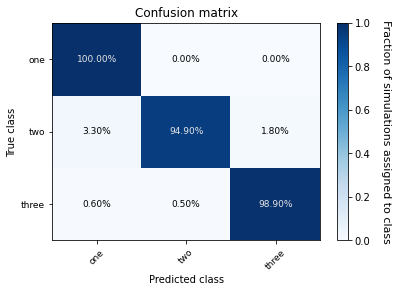

./testSims/Predictions/TrainWO_TestW_OU0125_pred.csv
[[998   1   1]
 [ 45 946   9]
 [ 24   3 973]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


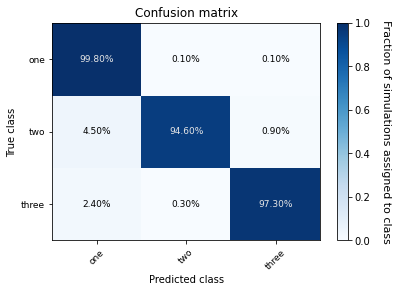

./testSims/Predictions/TrainWO_TestW_disc0125_pred.csv
[[1000    0    0]
 [  46  942   12]
 [   7   17  976]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


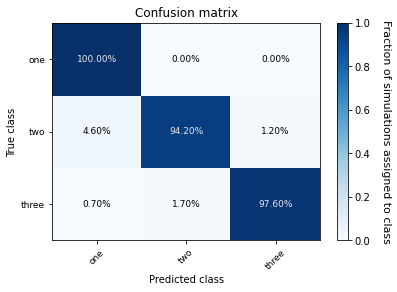

./testSims/Predictions/TrainWO_TestW_SNPs0125_pred.csv
[[1000    0    0]
 [ 112  888    0]
 [  49    0  951]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


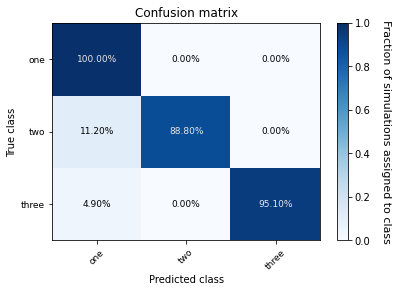

./testSims/Predictions/TrainWO_TestW_BM_SNPs0125_pred.csv
[[1000    0    0]
 [  10  989    1]
 [   1    0  999]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


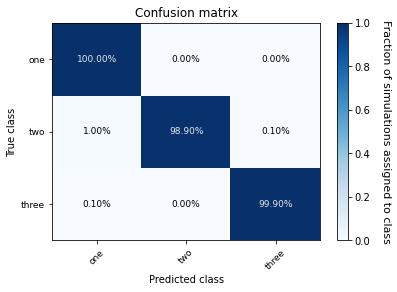

./testSims/Predictions/TrainWO_TestW_OU_SNPs0125_pred.csv
[[1000    0    0]
 [  14  986    0]
 [  11    0  989]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


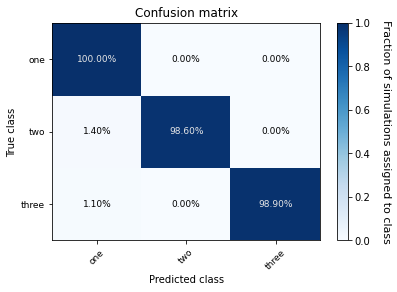

./testSims/Predictions/TrainWO_TestW_disc_SNPs0125_pred.csv
[[1000    0    0]
 [  48  952    0]
 [  11    1  988]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


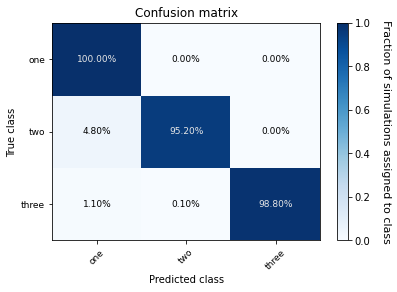

./testSims/Predictions/TrainWO_TestW_BM025_pred.csv
[[1000    0    0]
 [ 595  383   22]
 [ 454    7  539]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


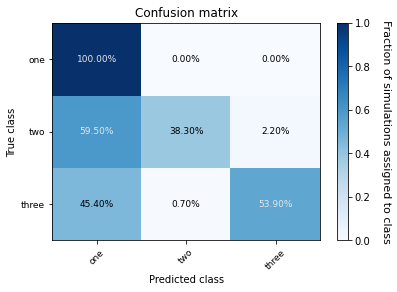

./testSims/Predictions/TrainWO_TestW_OU025_pred.csv
[[998   1   1]
 [643 344  13]
 [473  13 514]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


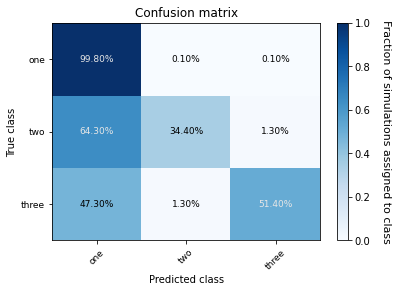

./testSims/Predictions/TrainWO_TestW_disc025_pred.csv
[[1000    0    0]
 [ 398  586   16]
 [ 216   53  731]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


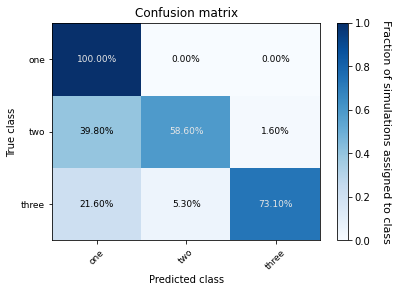

./testSims/Predictions/TrainWO_TestW_SNPs025_pred.csv
[[1000    0    0]
 [ 887  113    0]
 [ 889    0  111]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


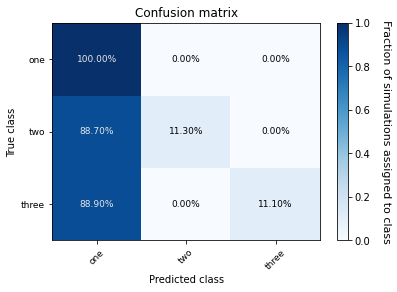

./testSims/Predictions/TrainWO_TestW_BM_SNPs025_pred.csv
[[1000    0    0]
 [ 622  364   14]
 [ 424    1  575]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


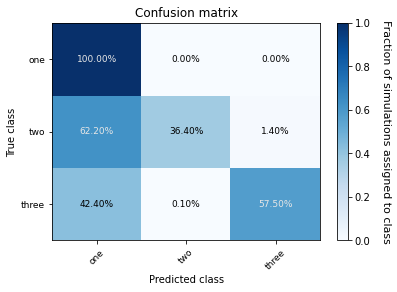

./testSims/Predictions/TrainWO_TestW_OU_SNPs025_pred.csv
[[1000    0    0]
 [ 747  253    0]
 [ 753    0  247]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


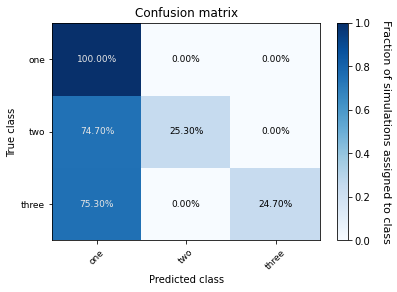

./testSims/Predictions/TrainWO_TestW_disc_SNPs025_pred.csv
[[1000    0    0]
 [ 803  197    0]
 [ 716    0  284]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


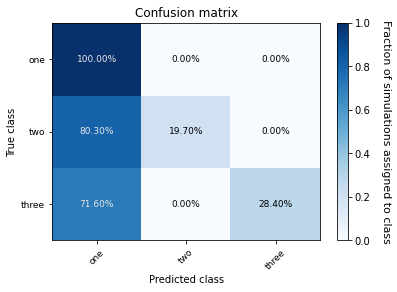

./testSims/Predictions/TrainWO_TestW_BM05_pred.csv
[[1000    0    0]
 [ 975   20    5]
 [ 913    3   84]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


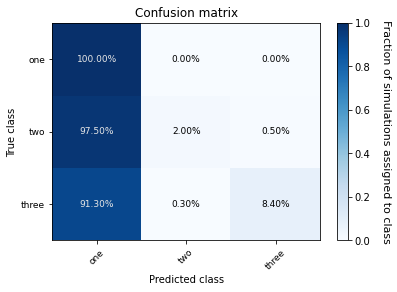

./testSims/Predictions/TrainWO_TestW_OU05_pred.csv
[[998   1   1]
 [961  30   9]
 [918   5  77]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


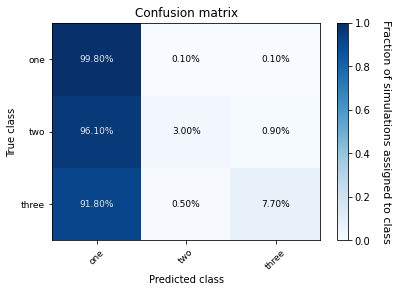

./testSims/Predictions/TrainWO_TestW_disc05_pred.csv
[[1000    0    0]
 [ 881  109   10]
 [ 765   37  198]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


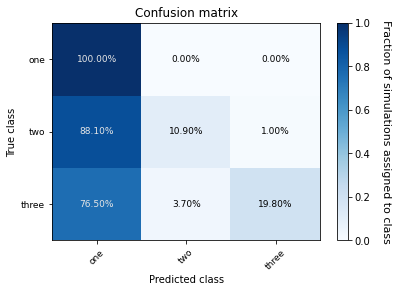

./testSims/Predictions/TrainWO_TestW_SNPs05_pred.csv
[[1000    0    0]
 [ 999    1    0]
 [1000    0    0]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


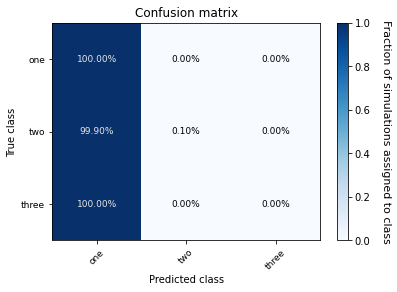

./testSims/Predictions/TrainWO_TestW_BM_SNPs05_pred.csv
[[1000    0    0]
 [ 991    5    4]
 [ 948    0   52]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


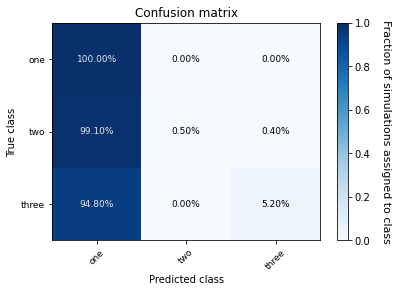

./testSims/Predictions/TrainWO_TestW_OU_SNPs05_pred.csv
[[1000    0    0]
 [ 994    6    0]
 [ 998    0    2]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


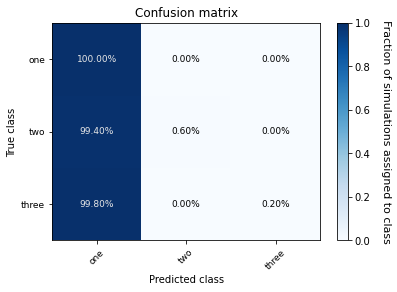

./testSims/Predictions/TrainWO_TestW_disc_SNPs05_pred.csv
[[1000    0    0]
 [ 999    1    0]
 [ 995    0    5]]


<ipython-input-20-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


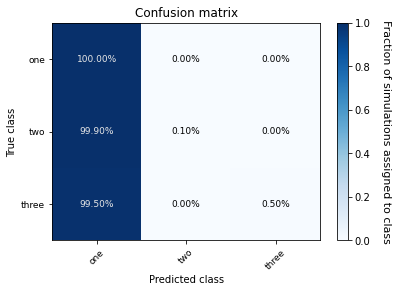

In [21]:
# Now we will plot the confusion matrices for each trained model
#first get the predictions
pred = model1.predict(np.swapaxes(traits_BM01, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_BM0125_pred.csv')

# get the predictions for the next dataset
pred = model2.predict(np.swapaxes(traits_OU01, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_OU0125_pred.csv')

# get the predictions
pred = model3.predict(np.swapaxes(traits_disc01, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_disc0125_pred.csv')

# get the predictions
pred = model4.predict(xtest01)
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_SNPs0125_pred.csv')

# get the predictions
pred = model5.predict([np.swapaxes(traits_BM01, 1, 2), xtest01])
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_BM_SNPs0125_pred.csv')

# get the predictions
pred = model6.predict([np.swapaxes(traits_OU01, 1, 2), xtest01])
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_OU_SNPs0125_pred.csv')

# get the predictions
pred = model7.predict([np.swapaxes(traits_disc01, 1, 2), xtest01])
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_disc_SNPs0125_pred.csv')

# get the predictions
pred = model1.predict(np.swapaxes(traits_BM05, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_BM025_pred.csv')

# get the predictions
pred = model2.predict(np.swapaxes(traits_OU05, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_OU025_pred.csv')

# get the predictions
pred = model3.predict(np.swapaxes(traits_disc05, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_disc025_pred.csv')

#first get the predictions
pred = model4.predict(xtest05)
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_SNPs025_pred.csv')

# get the predictions
pred = model5.predict([np.swapaxes(traits_BM05, 1, 2), xtest05])
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_BM_SNPs025_pred.csv')

#first get the predictions
pred = model6.predict([np.swapaxes(traits_OU05, 1, 2), xtest05])
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_OU_SNPs025_pred.csv')

# get the predictions
pred = model7.predict([np.swapaxes(traits_disc05, 1, 2), xtest05])
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_disc_SNPs025_pred.csv')

# get the predictions
pred = model1.predict(np.swapaxes(traits_BM1, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_BM05_pred.csv')

# get the predictions
pred = model2.predict(np.swapaxes(traits_OU1, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_OU05_pred.csv')

# get the predictions
pred = model3.predict(np.swapaxes(traits_disc1, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_disc05_pred.csv')

# get the predictions
pred = model4.predict(xtest1)
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_SNPs05_pred.csv')

# get the predictions
pred = model5.predict([np.swapaxes(traits_BM1, 1, 2), xtest1])
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_BM_SNPs05_pred.csv')

# get the predictions
pred = model6.predict([np.swapaxes(traits_OU1, 1, 2), xtest1])
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_OU_SNPs05_pred.csv')

# get the predictions
pred = model7.predict([np.swapaxes(traits_disc1, 1, 2), xtest1])
confusion_save(pred, './testSims/Predictions/TrainWO_TestW_disc_SNPs05_pred.csv')

In [4]:
# Now we will repeat the accuracy evaluation with models trained with migration. For that, we will build confusion matrices containing the true and predicted scenarions for each simulation on the test set.

# first import the libraries
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix

# load the trained models with migration.
model1 = load_model('./Trained_Models/Migration0125_Trained_Traits_Model_100BM.mod')
model2 = load_model('./Trained_Models/Migration0125_Trained_Traits_Model_100OU.mod')
model3 = load_model('./Trained_Models/Migration0125_Trained_Traits_Model_100disc.mod')
model4 = load_model('./Trained_Models/Migration0125_Trained_CNN_Model.mod')
model5 = load_model('./Trained_Models/Migration0125_Trained_Comb_Model_100BM.mod')
model6 = load_model('./Trained_Models/Migration0125_Trained_Comb_Model_100OU.mod')
model7 = load_model('./Trained_Models/Migration0125_Trained_Comb_Model_100disc.mod')
model8 = load_model('./Trained_Models/Migration025_Trained_Traits_Model_100BM.mod')
model9 = load_model('./Trained_Models/Migration025_Trained_Traits_Model_100OU.mod')
model10 = load_model('./Trained_Models/Migration025_Trained_Traits_Model_100disc.mod')
model11 = load_model('./Trained_Models/Migration025_Trained_CNN_Model.mod')
model12 = load_model('./Trained_Models/Migration025_Trained_Comb_Model_100BM.mod')
model13 = load_model('./Trained_Models/Migration025_Trained_Comb_Model_100OU.mod')
model14 = load_model('./Trained_Models/Migration025_Trained_Comb_Model_100disc.mod')
model15 = load_model('./Trained_Models/Migration05_Trained_Traits_Model_100BM.mod')
model16 = load_model('./Trained_Models/Migration05_Trained_Traits_Model_100OU.mod')
model17 = load_model('./Trained_Models/Migration05_Trained_Traits_Model_100disc.mod')
model18 = load_model('./Trained_Models/Migration05_Trained_CNN_Model.mod')
model19 = load_model('./Trained_Models/Migration05_Trained_Comb_Model_100BM.mod')
model20 = load_model('./Trained_Models/Migration05_Trained_Comb_Model_100OU.mod')
model21 = load_model('./Trained_Models/Migration05_Trained_Comb_Model_100disc.mod')

./testSims/Predictions/TrainW_TestW_BM0125_pred.csv
[[1000    0    0]
 [   0  993    7]
 [   0    5  995]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


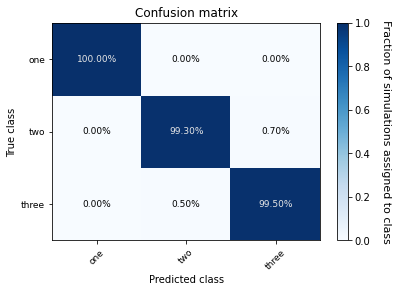

./testSims/Predictions/TrainW_TestW_OU0125_pred.csv
[[998   1   1]
 [  2 997   1]
 [  0   1 999]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


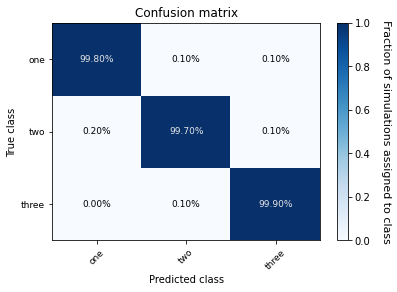

./testSims/Predictions/TrainW_TestW_disc0125_pred.csv
[[1000    0    0]
 [   6  988    6]
 [   0   13  987]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


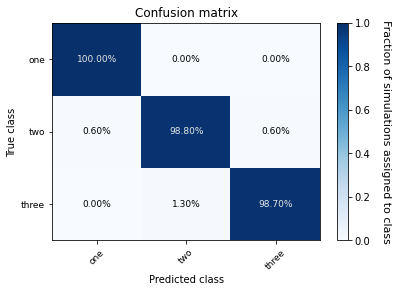

./testSims/Predictions/TrainW_TestW_SNPs0125_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    0 1000]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


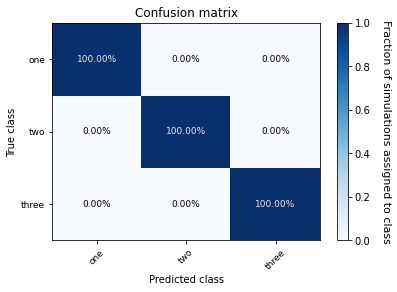

./testSims/Predictions/TrainW_TestW_BM_SNPs0125_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    0 1000]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


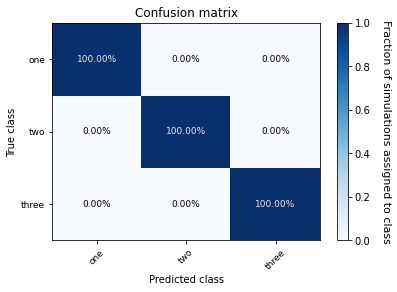

./testSims/Predictions/TrainW_TestW_OU_SNPs0125_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    0 1000]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


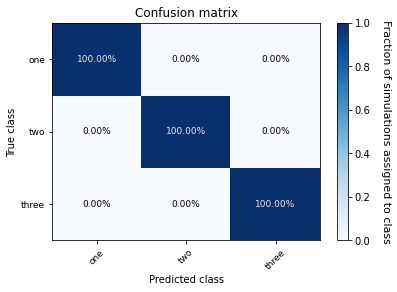

./testSims/Predictions/TrainW_TestW_disc_SNPs0125_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    0 1000]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


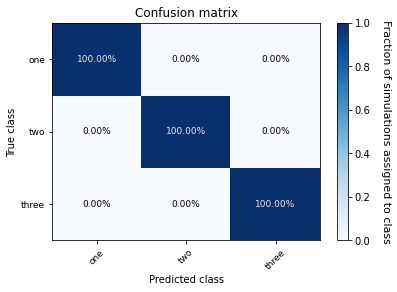

./testSims/Predictions/TrainW_TestW_BM025_pred.csv
[[992   6   2]
 [  1 970  29]
 [  0  23 977]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


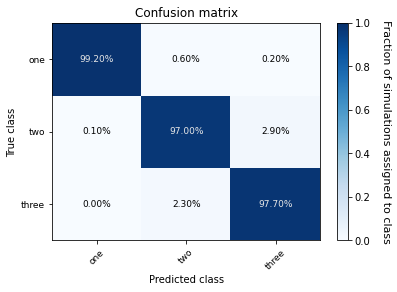

./testSims/Predictions/TrainW_TestW_OU025_pred.csv
[[993   1   6]
 [ 11 946  43]
 [  1  22 977]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


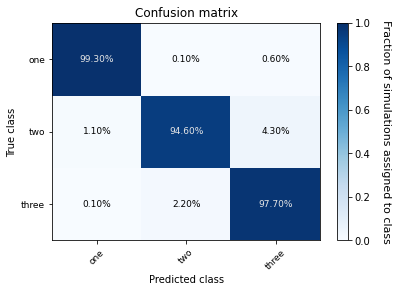

./testSims/Predictions/TrainW_TestW_disc025_pred.csv
[[982  15   3]
 [ 14 915  71]
 [  0  28 972]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


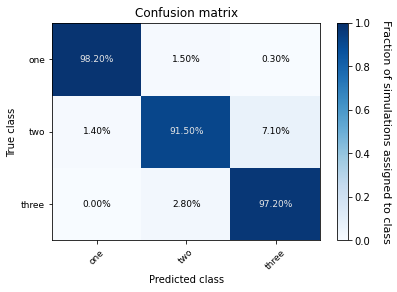

./testSims/Predictions/TrainW_TestW_SNPs025_pred.csv
[[998   2   0]
 [  0 996   4]
 [  2   4 994]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


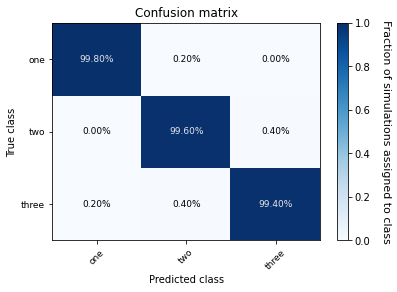

./testSims/Predictions/TrainW_TestW_BM_SNPs025_pred.csv
[[995   3   2]
 [  2 965  33]
 [  0  16 984]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


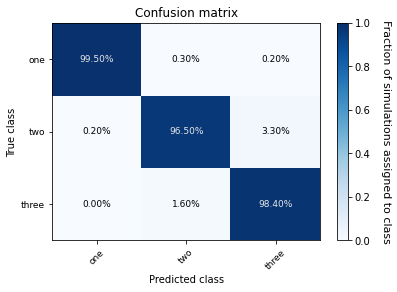

./testSims/Predictions/TrainW_TestW_OU_SNPs025_pred.csv
[[993   2   5]
 [ 14 941  45]
 [  0  20 980]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


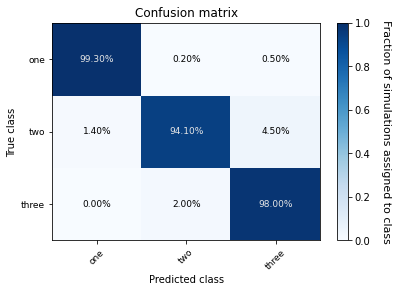

./testSims/Predictions/TrainW_TestW_disc_SNPs025_pred.csv
[[1000    0    0]
 [   0  998    2]
 [   1    0  999]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


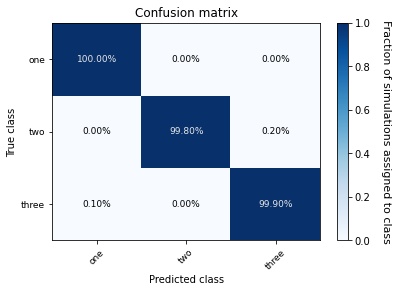

./testSims/Predictions/TrainW_TestW_BM05_pred.csv
[[912  83   5]
 [ 59 757 184]
 [  4 205 791]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


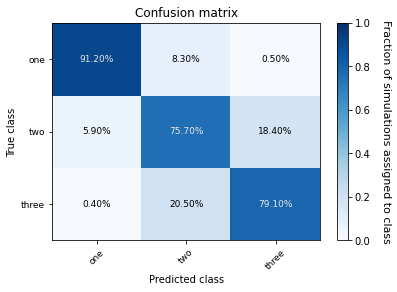

./testSims/Predictions/TrainW_TestW_OU05_pred.csv
[[935  54  11]
 [ 63 665 272]
 [ 10 138 852]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


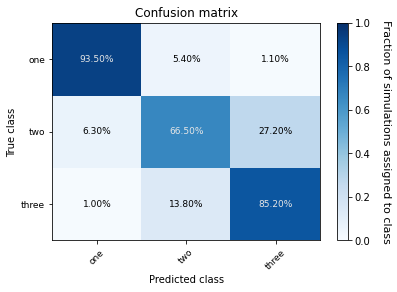

./testSims/Predictions/TrainW_TestW_disc05_pred.csv
[[917  79   4]
 [111 819  70]
 [ 21 356 623]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


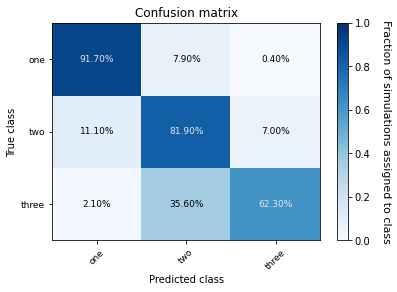

./testSims/Predictions/TrainW_TestW_SNPs05_pred.csv
[[691 119 190]
 [196 285 519]
 [263 242 495]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


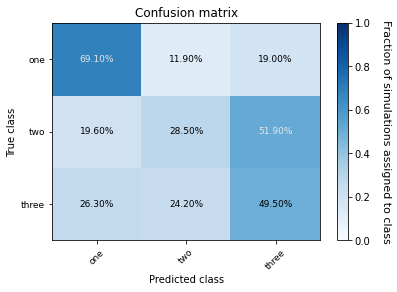

./testSims/Predictions/TrainW_TestW_BM_SNPs05_pred.csv
[[834 166   0]
 [ 29 938  33]
 [  2 101 897]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


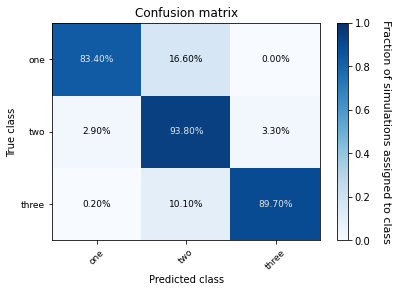

./testSims/Predictions/TrainW_TestW_OU_SNPs05_pred.csv
[[911  77  12]
 [ 81 584 335]
 [  7  98 895]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


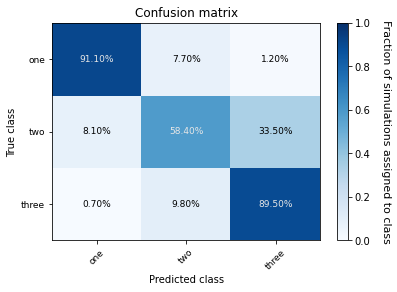

./testSims/Predictions/TrainW_TestW_disc_SNPs05_pred.csv
[[970  24   6]
 [  8 803 189]
 [  3 195 802]]


<ipython-input-36-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


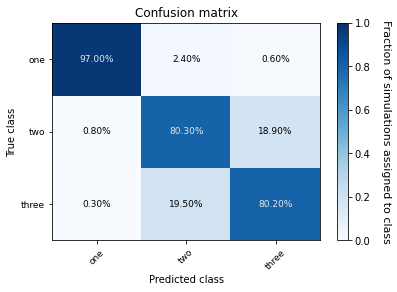

In [38]:
# Now we will plot the confusion matrices for each trained model
#first get the predictions
pred = model1.predict(np.swapaxes(traits_BM01, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainW_TestW_BM0125_pred.csv')

# get the predictions for the next dataset
pred = model2.predict(np.swapaxes(traits_OU01, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainW_TestW_OU0125_pred.csv')

# get the predictions
pred = model3.predict(np.swapaxes(traits_disc01, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainW_TestW_disc0125_pred.csv')

# get the predictions
pred = model4.predict(xtest01)
confusion_save(pred, './testSims/Predictions/TrainW_TestW_SNPs0125_pred.csv')

# get the predictions
pred = model5.predict([np.swapaxes(traits_BM01, 1, 2), xtest01])
confusion_save(pred, './testSims/Predictions/TrainW_TestW_BM_SNPs0125_pred.csv')

# get the predictions
pred = model6.predict([np.swapaxes(traits_OU01, 1, 2), xtest01])
confusion_save(pred, './testSims/Predictions/TrainW_TestW_OU_SNPs0125_pred.csv')

# get the predictions
pred = model7.predict([np.swapaxes(traits_disc01, 1, 2), xtest01])
confusion_save(pred, './testSims/Predictions/TrainW_TestW_disc_SNPs0125_pred.csv')

# get the predictions
pred = model8.predict(np.swapaxes(traits_BM05, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainW_TestW_BM025_pred.csv')

# get the predictions
pred = model9.predict(np.swapaxes(traits_OU05, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainW_TestW_OU025_pred.csv')

# get the predictions
pred = model10.predict(np.swapaxes(traits_disc05, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainW_TestW_disc025_pred.csv')

#first get the predictions
pred = model11.predict(xtest05)
confusion_save(pred, './testSims/Predictions/TrainW_TestW_SNPs025_pred.csv')

# get the predictions
pred = model12.predict([np.swapaxes(traits_BM05, 1, 2), xtest05])
confusion_save(pred, './testSims/Predictions/TrainW_TestW_BM_SNPs025_pred.csv')

#first get the predictions
pred = model13.predict([np.swapaxes(traits_OU05, 1, 2), xtest05])
confusion_save(pred, './testSims/Predictions/TrainW_TestW_OU_SNPs025_pred.csv')

# get the predictions
pred = model14.predict([np.swapaxes(traits_disc05, 1, 2), xtest05])
confusion_save(pred, './testSims/Predictions/TrainW_TestW_disc_SNPs025_pred.csv')

# get the predictions
pred = model15.predict(np.swapaxes(traits_BM1, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainW_TestW_BM05_pred.csv')

# get the predictions
pred = model16.predict(np.swapaxes(traits_OU1, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainW_TestW_OU05_pred.csv')

# get the predictions
pred = model17.predict(np.swapaxes(traits_disc1, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainW_TestW_disc05_pred.csv')

# get the predictions
pred = model18.predict(xtest1)
confusion_save(pred, './testSims/Predictions/TrainW_TestW_SNPs05_pred.csv')

# get the predictions
pred = model19.predict([np.swapaxes(traits_BM1, 1, 2), xtest1])
confusion_save(pred, './testSims/Predictions/TrainW_TestW_BM_SNPs05_pred.csv')

# get the predictions
pred = model20.predict([np.swapaxes(traits_OU1, 1, 2), xtest1])
confusion_save(pred, './testSims/Predictions/TrainW_TestW_OU_SNPs05_pred.csv')

# get the predictions
pred = model21.predict([np.swapaxes(traits_disc1, 1, 2), xtest1])
confusion_save(pred, './testSims/Predictions/TrainW_TestW_disc_SNPs05_pred.csv')

In [5]:
# load the traits simulated under the BM model for the 3 scenarios without migration. 
traits_BM = []
traits_BM = np.loadtxt("../NoMigration/traits/traits_BM.txt").reshape(30000,-1,100)
# transform into a NumPy array. 
traits_BM = np.array(traits_BM)

#Use standard scaling for the continuous traits.
scalers_BM = {}
for i in range(traits_BM.shape[2]):
    scalers_BM[i] = StandardScaler(copy=False)
    traits_BM[:, :, i] = scalers_BM[i].fit_transform(traits_BM[:, :, i]) 

# load the traits simulated under the OU model for the 3 scenarios without migration. 
traits_OU = []
traits_OU = np.loadtxt("../NoMigration/traits/traits_OU.txt").reshape(30000,-1,100)
# transform into a NumPy array. 
traits_OU = np.array(traits_OU)

#Use standard scaling for the continuous traits
scalers_OU = {}
for i in range(traits_OU.shape[2]):
    scalers_OU[i] = StandardScaler(copy=False)
    traits_OU[:, :, i] = scalers_OU[i].fit_transform(traits_OU[:, :, i]) 

In [6]:
#Now predict the data simulated without migration using the networks trained with migration.

# load the traits simulated under the BM model for the 3 scenarios without migration.
traits_BM = []
traits_BM = np.loadtxt("../NoMigration/testSims/traits/traits_BM.txt").reshape(3000,-1,100)
# transform into a NumPy array.
traits_BM = np.array(traits_BM)

#Use standard scaling for the continuous traits.
for i in range(traits_BM.shape[2]):
    traits_BM[:, :, i] = scalers_BM[i].transform(traits_BM[:, :, i]) 

# load the traits simulated under the OU model for the 3 scenarios without migration. 
traits_OU = []
traits_OU = np.loadtxt("../NoMigration/testSims/traits/traits_OU.txt").reshape(3000,-1,100)
# transform into a NumPy array. 
traits_OU = np.array(traits_OU)

#Use standard scaling for the continuous traits.
for i in range(traits_OU.shape[2]):
    traits_OU[:, :, i] = scalers_OU[i].transform(traits_OU[:, :, i])

# load the discrete traits simulated for the 3 scenarios without migration.
traits_disc = []
traits_disc = np.loadtxt("../NoMigration/testSims/traits/traits_disc.txt").reshape(3000,-1,100)
# transform into a NumPy array. 
traits_disc = np.array(traits_disc)

# load the SNPs simulated for the 3 scenarios without migration. 
u1 = np.load("../NoMigration/testSims/Model_1sp.npz",mmap_mode='r')
u2 = np.load("../NoMigration/testSims/Model_2sp.npz",mmap_mode='r')
u3 = np.load("../NoMigration/testSims/Model_3sp.npz",mmap_mode='r')

xtest=np.concatenate((u1['Model_1sp'],u2['Model_2sp'],u3['Model_3sp']),axis=0)

#transform major alleles in -1 and minor in 1.
for arr,array in enumerate(xtest):
    for idx,row in enumerate(array):
        if np.count_nonzero(row) > len(row)/2:
            xtest[arr][idx][xtest[arr][idx] == 1] = -1
            xtest[arr][idx][xtest[arr][idx] == 0] = 1
        else:
            xtest[arr][idx][xtest[arr][idx] == 0] = -1

# create a label vector in the same order as the simulations.
ytest=[0 for i in range(len(u1['Model_1sp']))]
ytest.extend([1 for i in range(len(u2['Model_2sp']))])
ytest.extend([2 for i in range(len(u3['Model_3sp']))])
ytest = np.array(ytest)

./testSims/Predictions/TrainW_TestWO_BM0125_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0   12  988]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


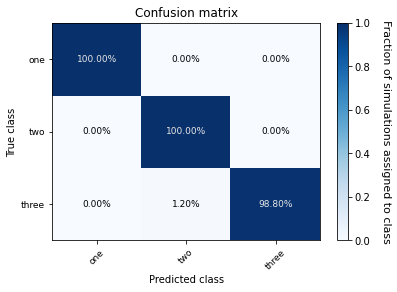

./testSims/Predictions/TrainW_TestWO_OU0125_pred.csv
[[ 998    1    1]
 [   0 1000    0]
 [   0    3  997]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


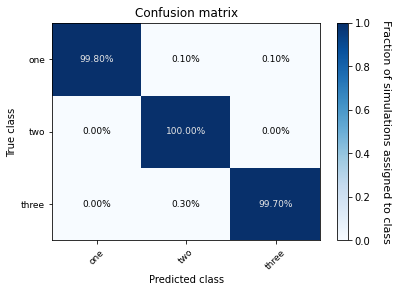

./testSims/Predictions/TrainW_TestWO_disc0125_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    0 1000]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


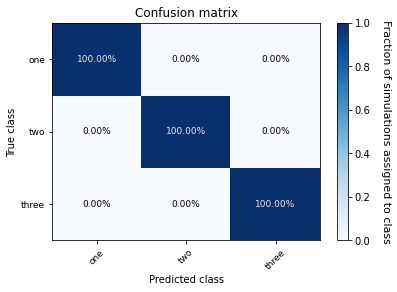

./testSims/Predictions/TrainW_TestWO_SNPs0125_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    1  999]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


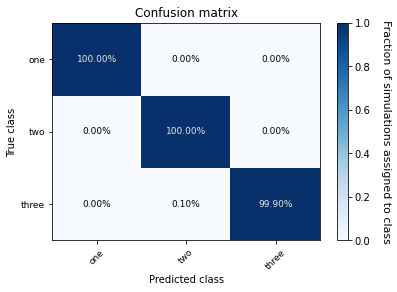

./testSims/Predictions/TrainW_TestWO_BM_SNPs0125_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    3  997]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


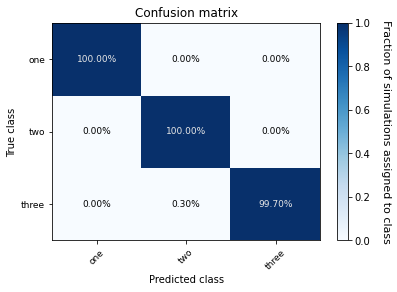

./testSims/Predictions/TrainW_TestWO_OU_SNPs0125_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    1  999]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


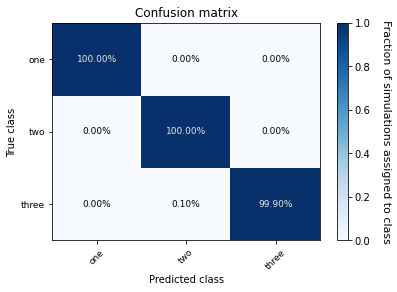

./testSims/Predictions/TrainW_TestWO_disc_SNPs0125_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    7  993]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


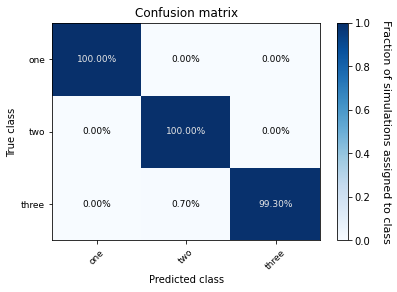

./testSims/Predictions/TrainW_TestWO_BM025_pred.csv
[[ 994    5    1]
 [   0 1000    0]
 [   0   15  985]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


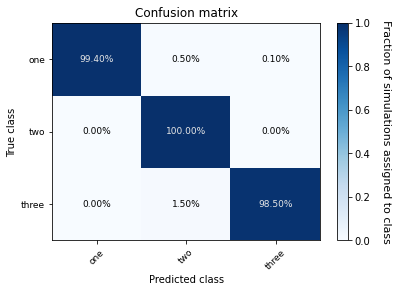

./testSims/Predictions/TrainW_TestWO_OU025_pred.csv
[[ 993    1    6]
 [   0 1000    0]
 [   0    0 1000]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


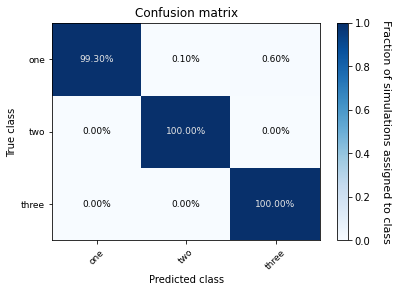

./testSims/Predictions/TrainW_TestWO_disc025_pred.csv
[[ 982   15    3]
 [   0  997    3]
 [   0    0 1000]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


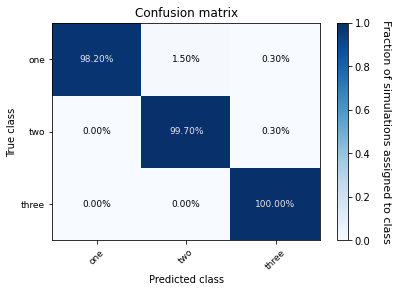

./testSims/Predictions/TrainW_TestWO_SNPs025_pred.csv
[[ 998    2    0]
 [   0 1000    0]
 [   0    3  997]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


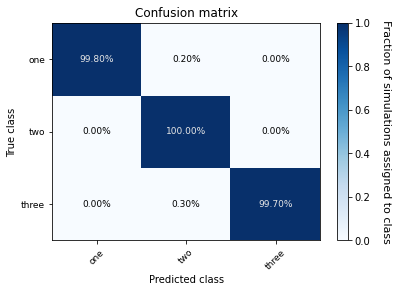

./testSims/Predictions/TrainW_TestWO_BM_SNPs025_pred.csv
[[ 998    1    1]
 [   0 1000    0]
 [   0    8  992]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


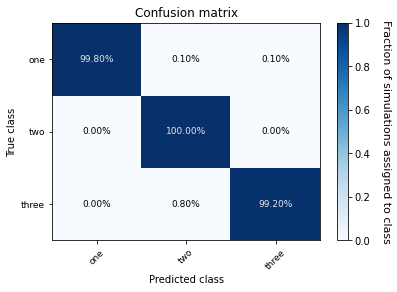

./testSims/Predictions/TrainW_TestWO_OU_SNPs025_pred.csv
[[ 993    2    5]
 [   0  999    1]
 [   0    0 1000]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


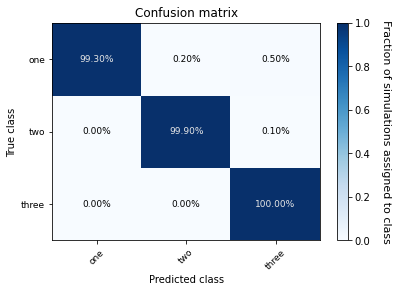

./testSims/Predictions/TrainW_TestWO_disc_SNPs025_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    2  998]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


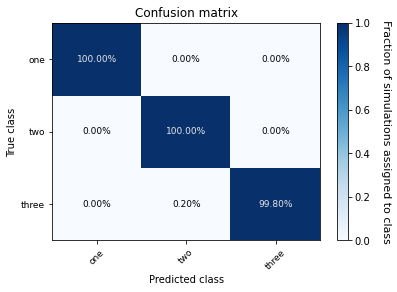

./testSims/Predictions/TrainW_TestWO_BM05_pred.csv
[[ 935   60    5]
 [   0  985   15]
 [   0    0 1000]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


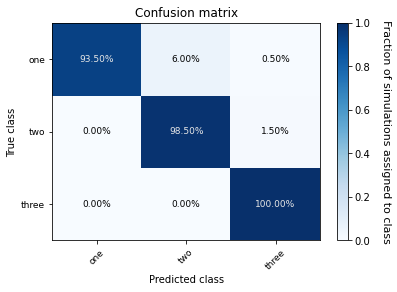

./testSims/Predictions/TrainW_TestWO_OU05_pred.csv
[[931  58  11]
 [  0 993   7]
 [  0   1 999]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


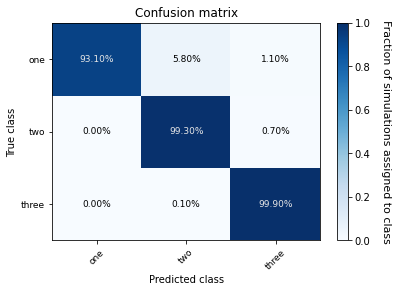

./testSims/Predictions/TrainW_TestWO_disc05_pred.csv
[[ 917   79    4]
 [   0  975   25]
 [   0    0 1000]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


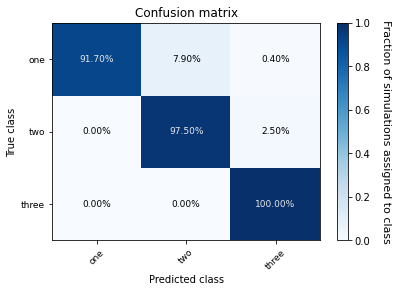

./testSims/Predictions/TrainW_TestWO_SNPs05_pred.csv
[[691 119 190]
 [166 438 396]
 [ 40 199 761]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


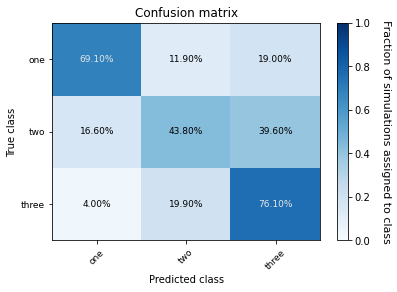

./testSims/Predictions/TrainW_TestWO_BM_SNPs05_pred.csv
[[ 882  118    0]
 [   0  707  293]
 [   0    0 1000]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


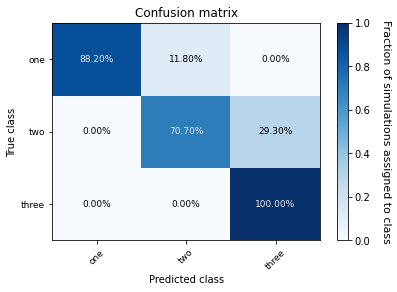

./testSims/Predictions/TrainW_TestWO_OU_SNPs05_pred.csv
[[ 910   78   12]
 [   0  201  799]
 [   0    0 1000]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


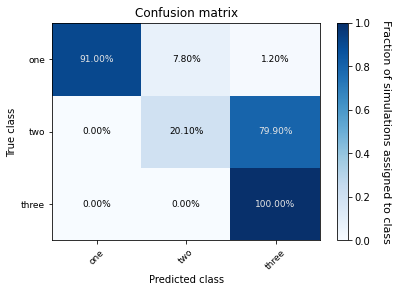

./testSims/Predictions/TrainW_TestWO_disc_SNPs05_pred.csv
[[ 970   24    6]
 [   0  979   21]
 [   0    0 1000]]


<ipython-input-9-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


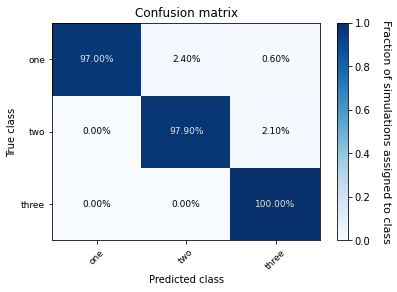

In [11]:
# Now we will plot the confusion matrices for each trained model
#first get the predictions
pred = model1.predict(np.swapaxes(traits_BM, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_BM0125_pred.csv')

# get the predictions for the next dataset
pred = model2.predict(np.swapaxes(traits_OU, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_OU0125_pred.csv')

# get the predictions
pred = model3.predict(np.swapaxes(traits_disc, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_disc0125_pred.csv')

# get the predictions
pred = model4.predict(xtest)
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_SNPs0125_pred.csv')

# get the predictions
pred = model5.predict([np.swapaxes(traits_BM, 1, 2), xtest])
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_BM_SNPs0125_pred.csv')

# get the predictions
pred = model6.predict([np.swapaxes(traits_OU, 1, 2), xtest])
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_OU_SNPs0125_pred.csv')

# get the predictions
pred = model7.predict([np.swapaxes(traits_disc, 1, 2), xtest])
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_disc_SNPs0125_pred.csv')

# get the predictions
pred = model8.predict(np.swapaxes(traits_BM, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_BM025_pred.csv')

# get the predictions
pred = model9.predict(np.swapaxes(traits_OU, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_OU025_pred.csv')

# get the predictions
pred = model10.predict(np.swapaxes(traits_disc, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_disc025_pred.csv')

#first get the predictions
pred = model11.predict(xtest)
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_SNPs025_pred.csv')

# get the predictions
pred = model12.predict([np.swapaxes(traits_BM, 1, 2), xtest])
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_BM_SNPs025_pred.csv')

#first get the predictions
pred = model13.predict([np.swapaxes(traits_OU, 1, 2), xtest])
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_OU_SNPs025_pred.csv')

# get the predictions
pred = model14.predict([np.swapaxes(traits_disc, 1, 2), xtest])
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_disc_SNPs025_pred.csv')

# get the predictions
pred = model15.predict(np.swapaxes(traits_BM, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_BM05_pred.csv')

# get the predictions
pred = model16.predict(np.swapaxes(traits_OU, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_OU05_pred.csv')

# get the predictions
pred = model17.predict(np.swapaxes(traits_disc, 1, 2))
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_disc05_pred.csv')

# get the predictions
pred = model18.predict(xtest)
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_SNPs05_pred.csv')

# get the predictions
pred = model19.predict([np.swapaxes(traits_BM, 1, 2), xtest])
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_BM_SNPs05_pred.csv')

# get the predictions
pred = model20.predict([np.swapaxes(traits_OU, 1, 2), xtest])
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_OU_SNPs05_pred.csv')

# get the predictions
pred = model21.predict([np.swapaxes(traits_disc, 1, 2), xtest])
confusion_save(pred, './testSims/Predictions/TrainW_TestWO_disc_SNPs05_pred.csv')